# 0 - Configuración del Entorno y Carga de Datos

## 0.1) Carga de librerías

In [ ]:
import warnings
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_val_score, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PowerTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## 0.2) Configuración de parámetros globales de visualización

In [ ]:
warnings.filterwarnings('ignore')
# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})

sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 2.2.3
numpy: 2.1.3


## 0.3) Carga del dataset

In [ ]:
df = pd.read_csv('house-prices-tp.csv')


# 1 - Análisis Exploratorio de Datos (EDA)

## 1 - 0) Introducción al dataset

El dataset contiene informacion de precios de casas de Boston con las siguientes variables:

| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `CRIM` | Continua | tasa de criminalidad per cápita por ciudad  |
| `ZN` | Continua | proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados |
| `INDUS` | Continua | proporción de acres de negocios no minoristas por ciudad |
| `CHAS` | Cualitativa | variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario) |
| `NOX` | Continua | concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
| `RM` | Continua | número promedio de habitaciones por vivienda |
| `AGE` | Continua | proporción de unidades ocupadas por sus propietarios construidas antes de 1940|
| `DIS` | Continua | distancias ponderadas a cinco centros de empleo de Boston|
| `RAD` | Continua | índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k] (Ejemplo: si TAX = 500, entonces el impuesto promedio es 5%) |
| `PTRATIO` | Continua | proporción alumno-maestro por ciudad |
| `B` | Continua | El resultado de la ecuación $$B = 1000(B_k - 0.63)^2$$ donde $$B_k$$ es la proporciòn de negros por ciudad |
| `LSTAT` | Continua | % de población de menor estatus socioeconómico |
| `MEDV` | Continua | Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$] |


El dataset original proviene del paper **"Hedonic Housing Prices and the Demand for Clean Air"** (DAVID HARRISON Jr, DANIEL L. RUBINFELD) de 1976.


En éste se realiza un estudio econometrico para estudiar los problemas metodologicos al intentar medir cuanto influye la calidad del aire respecto la disposicion a pagar por el precio de las viviendas.


Cada observación se corresponde con un distrito, pueblo o zona censal (census tract) del área metropolitana de Boston (no una vivienda individual), por lo que muchas de las variables provienen de agregaciones de viviendas individuales para dicha unidad.

## 1 - 1) Inspección preliminar

In [ ]:
#Dimensiones y primeros registros
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print("Primeros 10 registros:")
print("="*60)
df.head(10)


Dimensiones del dataset: 556 filas x 14 columnas
Primeros 10 registros:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
5,0.0626,0.0000,11.9300,0.0000,0.5730,6.5930,69.1000,2.4786,1.0000,273.0000,21.0000,391.9900,9.6700,22.4000
6,0.3581,0.0000,6.2000,1.0000,0.5070,6.9510,88.5000,2.8617,8.0000,307.0000,17.4000,391.7000,9.7100,26.7000
7,0.0883,0.0000,10.8100,0.0000,0.4130,6.4170,6.6000,5.2873,4.0000,305.0000,19.2000,383.7300,6.7200,24.2000
8,1.3547,0.0000,8.1400,0.0000,0.5380,6.0720,100.0000,4.1750,4.0000,307.0000,21.0000,376.7300,13.0400,14.5000
9,0.3035,0.0000,7.3800,0.0000,0.4930,6.3120,28.9000,5.4159,5.0000,287.0000,19.6000,396.9000,6.1500,23.0000


Observaciones:


*   El dataset original cuenta con 556 filas y 14 columnas.
*   `MEDV` será nuestra variable objetivo para la cual, a priori, contamos con 13 predictores.
*   `RAD` parece ser una variable categorica ordinal pero es un indice -> Redondear y cambiar tipo
*   `CHAS` es ser una variable binaria. -> Cambiar tipo
*   `ZN` parece contener muchos valores 0 -> Considerar cambiar tipo

In [ ]:
# Frecuencia de valores variables candidatas a categóricas
print("\nFrecuencia de valores en el índice de autopistas (RAD):")
print("=" * 60)
display(df['RAD'].value_counts())
print("\nFrecuencia de valores en la varible de limite con el río (CHAS):")
print("=" * 60)
display(df['CHAS'].value_counts())


Frecuencia de valores en el índice de autopistas (RAD):


,count
RAD,
24.0000,132
5.0000,115
4.0000,110
3.0000,38
6.0000,26
2.0000,24
8.0000,24
1.0000,20
7.0000,17



Frecuencia de valores en la varible de limite con el río (CHAS):


,count
CHAS,
0.0000,485
1.0000,48


Claramente `RAD` es un indice ordinal construido del 1 al 8 donde 24 tiene un significado especial

In [ ]:
# Frecuencia de valores ZN
print("\nFrecuencia de valores ZN:")
print("=" * 60)
display(df['ZN'].value_counts())



Frecuencia de valores ZN:


,count
ZN,
0.0000,372
20.0000,21
80.0000,15
22.0000,10
25.0000,10
12.5000,10
40.0000,7
45.0000,6
30.0000,6


Observamos que `ZN` tiene muchos valores nulos. Consideramos convertirla en una variable dicotomica más adelante.

In [ ]:
# Frecuencia de valores CRIM
print("\nFrecuencia de valores CRIM:")
print("=" * 60)
display(df['CRIM'].value_counts())



Frecuencia de valores CRIM:


,count
CRIM,
14.3337,2
0.0150,2
0.9762,1
0.0354,1
0.0110,1
...,...
0.0565,1
0.0951,1
0.6719,1


Posiblemente CRIM tenga muchos valores muy cercanos a cero,

In [ ]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 50)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


## 1 - 2) Preparación de datos (Data Wrangling)

Transformamos la variable RAD

In [ ]:
def transformar_rad(val):
  # Si el valor es nulo (NaN), lo dejamos como NaN
  if pd.isna(val):
    return np.nan

  # Los valores altos son errores de predicción del modelo para la categoría 24
  if val > 12:
    return 24
  else:
    # Redondear al entero más cercano y limitar entre 1 y el máximo de 5
    redondeado = round(val)
    return int(max(1, min(5, redondeado)))




In [ ]:
df['RAD'].value_counts()

,count
RAD,
24.0000,132
5.0000,115
4.0000,110
3.0000,38
6.0000,26
2.0000,24
8.0000,24
1.0000,20
7.0000,17


Eliminamos la variable B

In [ ]:
df = df.drop(columns = 'B')
print('Columnas restantes:', df.columns.tolist())

Columnas restantes: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']


Clasificamos las variables por tipo

In [ ]:
# Cambio la variable CHAS al tipo correcto
df['CHAS'] = df['CHAS'].astype('category')
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (12): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']
Variables categoricas (1): ['CHAS']


Consideramos que utilizar indicadores raciales para predecir precios de viviendas incorpora y legitima sesgos históricos de discriminación racial en el algoritmo. Un modelo predictivo no debería codificar la raza ni características demográficas de poblaciones minoritarias como factores determinantes o penalizadores del valor de una propiedad, ya que perpetúa desigualdades sistémicas.

Mas alla de que se trata de un ejercicio académico, consideramos esta una buena práctica.

## 1 -3) Analisis Descriptivo

### 1.3.1) Estadísticas descriptivas (tendencia central y dispersion)

In [ ]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.8455,0.3153,13.8286,236.5681,0.0063,0.0845,0.3153,4.8714,88.9762,3.7467,15.2487
ZN,13.1972,0.0000,24.9030,188.6993,0.0000,0.0000,0.0000,20.0000,100.0000,1.9578,2.7498
INDUS,11.2187,9.6900,6.9420,61.8789,0.4600,5.1300,9.6900,18.1000,27.7400,0.3015,-1.2064
NOX,0.5600,0.5380,0.1195,21.3325,0.3850,0.4530,0.5380,0.6440,0.8710,0.6944,-0.2296
RM,6.2918,6.2080,0.7824,12.4352,3.5610,5.8755,6.2080,6.6385,8.7800,0.3738,1.5551
AGE,67.6323,76.5000,28.4619,42.0833,2.9000,42.2750,76.5000,93.8250,100.0000,-0.5507,-1.0382
DIS,3.9441,3.3401,2.2557,57.1914,1.1296,2.1121,3.3401,5.4007,12.1265,1.0789,0.7054
RAD,9.6994,5.0000,8.6845,89.5366,1.0000,4.0000,5.0000,23.6327,24.0000,0.9515,-0.9478
TAX,409.5751,335.0000,167.6894,40.9423,187.0000,279.0000,335.0000,666.0000,711.0000,0.6323,-1.1705
PTRATIO,18.4299,19.0000,2.1948,11.9087,12.6000,17.0000,19.0000,20.2000,22.0000,-0.7872,-0.3048


Aunque algunas variables presentan dispersion considerable, los datos no parecen estar dentro de rangos imposibles (validacion por rango).

### 1.3.2) Interpretacion de sesgo y curtosis

In [ ]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
      CRIM: sesgo=+3.747 [sesgo positivo (alto)], curtosis=+15.249 [leptocurtica (colas pesadas)]
        ZN: sesgo=+1.958 [sesgo positivo (alto)], curtosis=+2.750 [leptocurtica (colas pesadas)]
     INDUS: sesgo=+0.302 [aproximadamente simetrica], curtosis=-1.206 [platicurtica (colas livianas)]
       NOX: sesgo=+0.694 [sesgo positivo (moderado)], curtosis=-0.230 [mesocurtica]
        RM: sesgo=+0.374 [aproximadamente simetrica], curtosis=+1.555 [leptocurtica (colas pesadas)]
       AGE: sesgo=-0.551 [sesgo negativo (moderado)], curtosis=-1.038 [platicurtica (colas livianas)]
       DIS: sesgo=+1.079 [sesgo positivo (alto)], curtosis=+0.705 [leptocurtica (colas pesadas)]
       RAD: sesgo=+0.951 [sesgo positivo (moderado)], curtosis=-0.948 [platicurtica (colas livianas)]
       TAX: sesgo=+0.632 [sesgo positivo (moderado)], curtosis=-1.171 [platicurtica (colas livianas)]
   PTRATIO: sesgo=-0.787 [sesgo negativo (moderado)], curtosis=-0.305 [mesocur

Variables con Sesgo Extremo: `CRIM`, `ZN`, .


Para estas variables se deberia emplear mas adelante **transformaciones logaritmicas** (buscar distribucion log-normal) o bien utilizar **escaladores robustos** (`RobustScaler`).

### 1.3.3) Graficos de distribución univariable

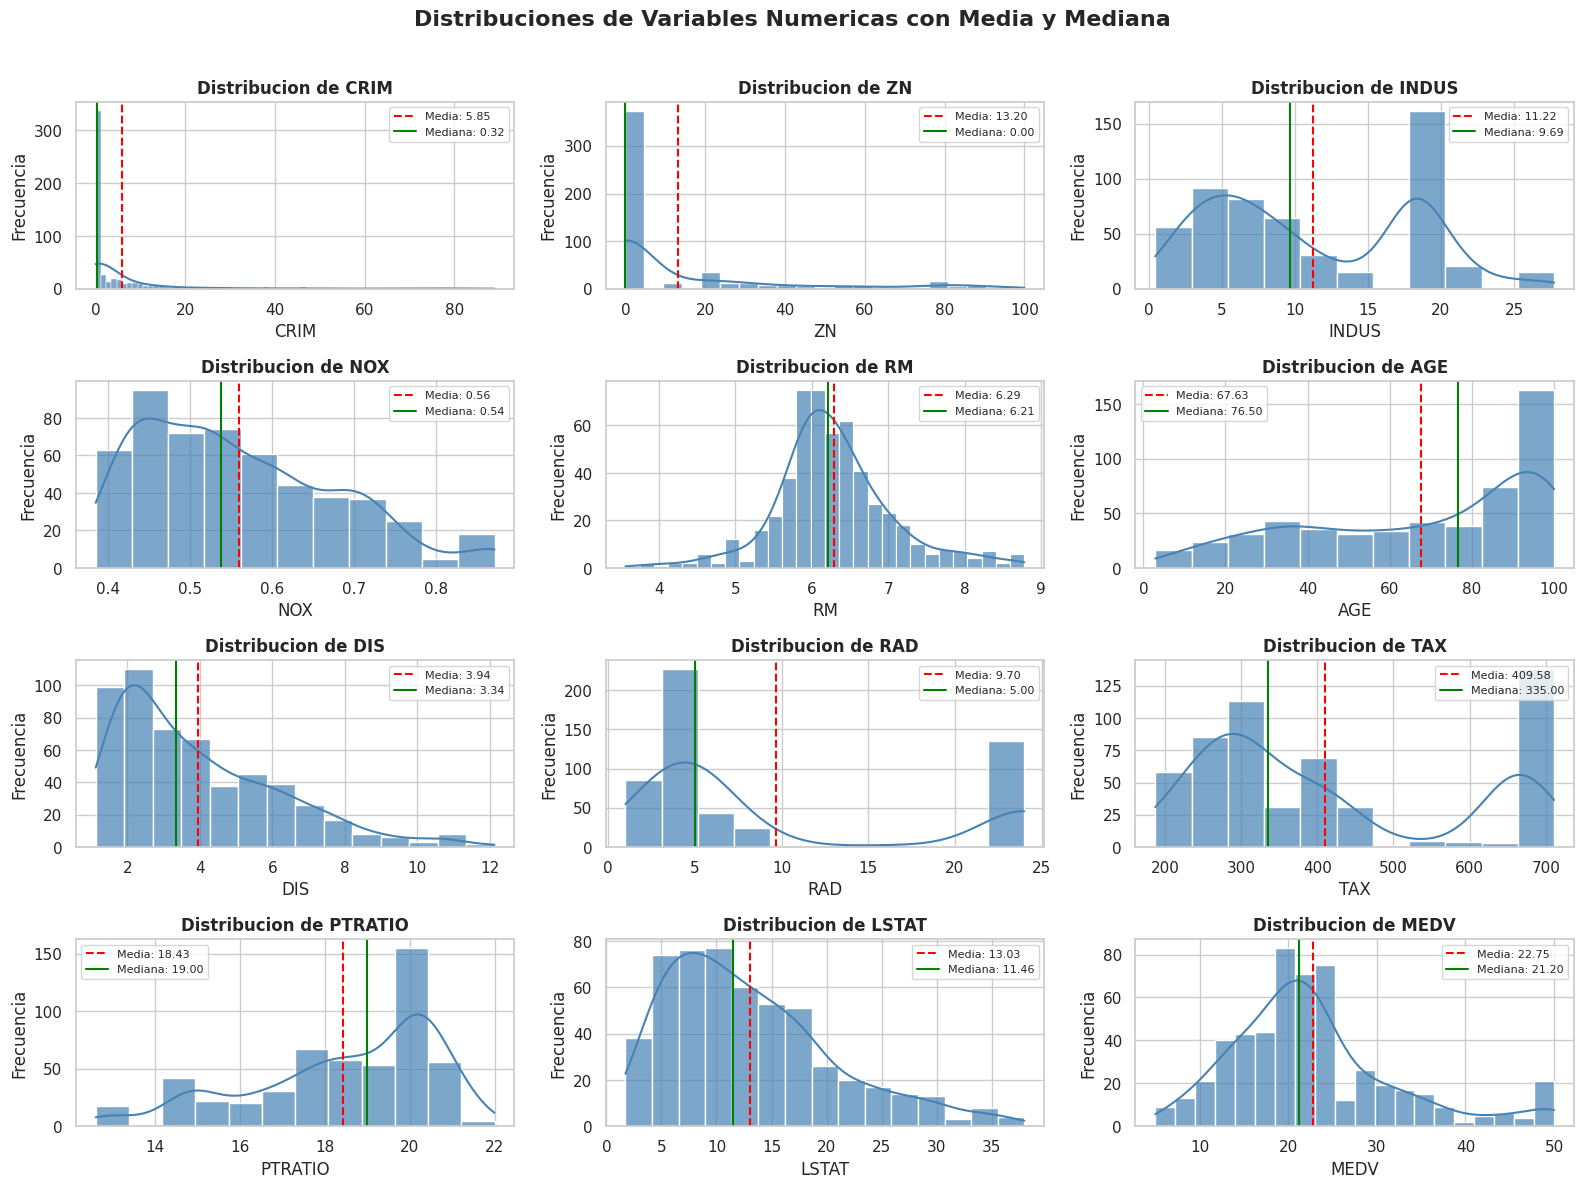

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(16
, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Conclusion para punto 3.1:



*   `CRIM`, `ZN`, `LSTAT` y `DIS` son candidatas para aplicar transformacion logaritmica (NOX no, aunque visualmente lo parece el sesgo es moderado) pues muestran fuerte sesgo positivo.

*   `B`, `AGE` son candidatas para aplicar transformacion exponencial pues muestran fuerte sesgo negativo.
*   `PTRATIO`, `TAX` e `INDUS` presentan multimodalidad.






## 1.4) Analisis de Correlacion

### 1.4.1) Matrices de Correlacion

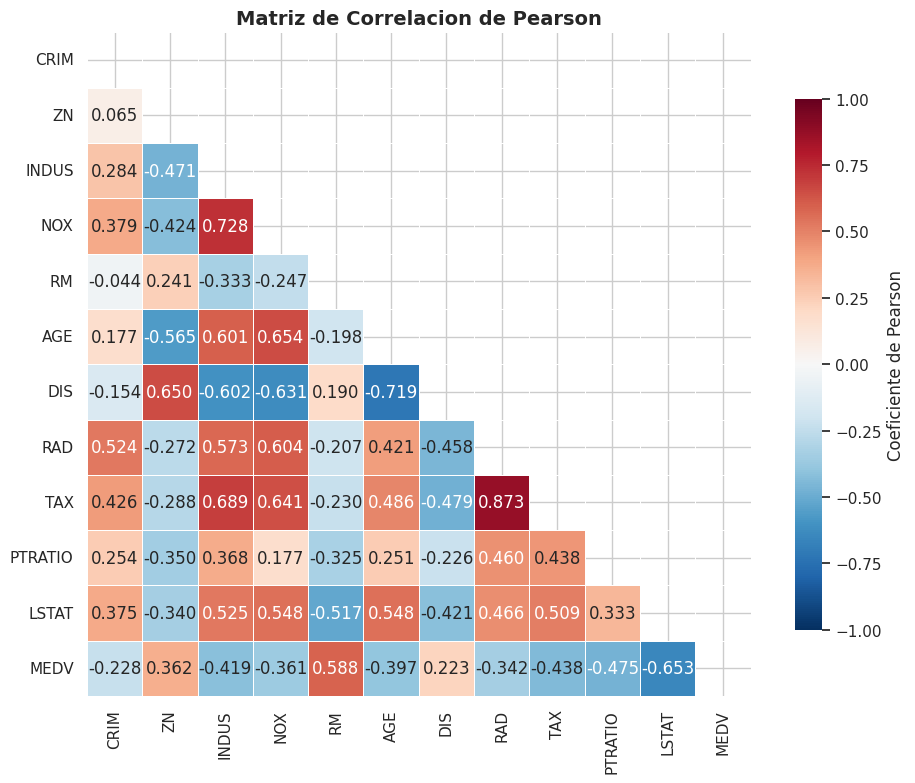

In [ ]:
corr_pearson = df[cols_numericas].corr(method='pearson')

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

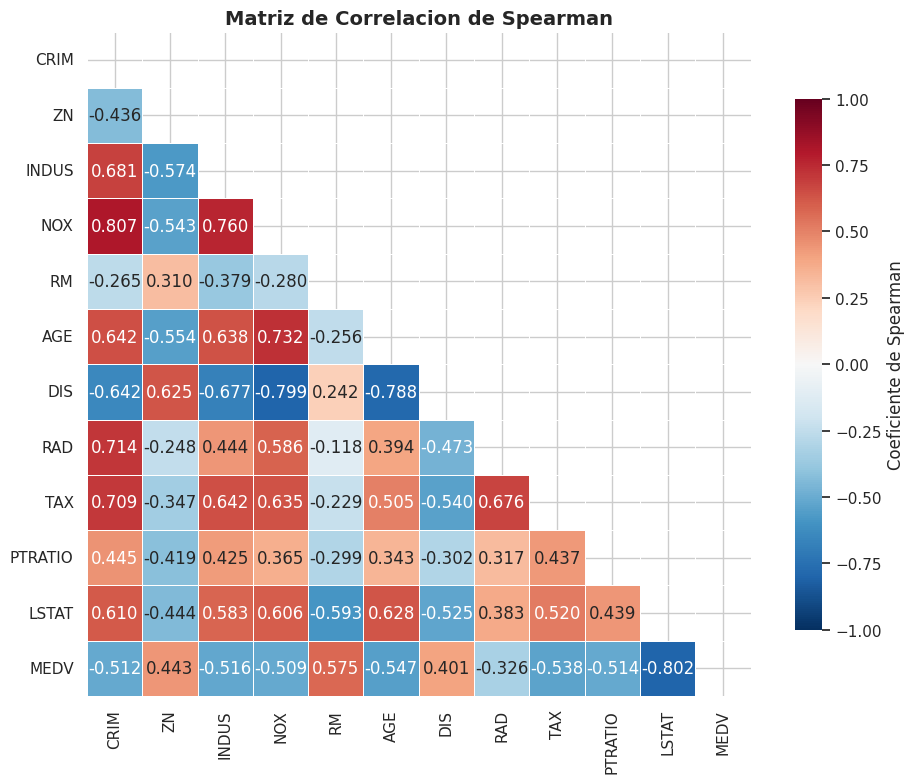

In [ ]:

corr_spearman = df[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

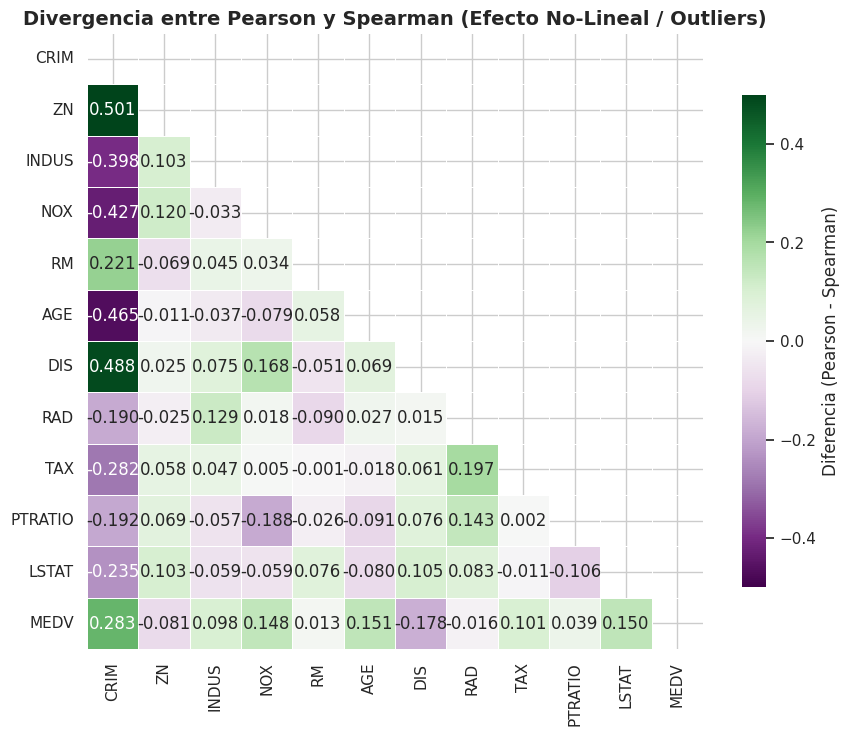

In [ ]:

diff_corr = corr_pearson - corr_spearman

mask_diff = np.triu(np.ones_like(diff_corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    diff_corr,
    mask=mask_diff,
    annot=True,
    fmt='.3f',
    cmap='PRGn',  # Un mapa divergente (ej. Púrpura/Verde) ideal para diferencias
    center=0,
    vmin=-0.5,
    vmax=0.5,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Diferencia (Pearson - Spearman)'},
)

plt.title(
    'Divergencia entre Pearson y Spearman (Efecto No-Lineal / Outliers)',
    fontsize=14,
    fontweight='bold',
)
plt.show()

### 1.4.2) Prueba de Colinealidad

In [ ]:
UMBRAL_COLINEALIDAD = 0.80

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.8 (posible colinealidad):
  RAD <-> TAX: r = 0.8731

Se detectaron 1 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


Entre `TAX` y `RAD`, elegimos Tax pues presenta mayor correlacion con MEDV

In [ ]:
df = df.drop(columns = 'RAD')
cols_numericas.remove('RAD')

### 1.4.3) Inspeccion visual de relacion entre variables

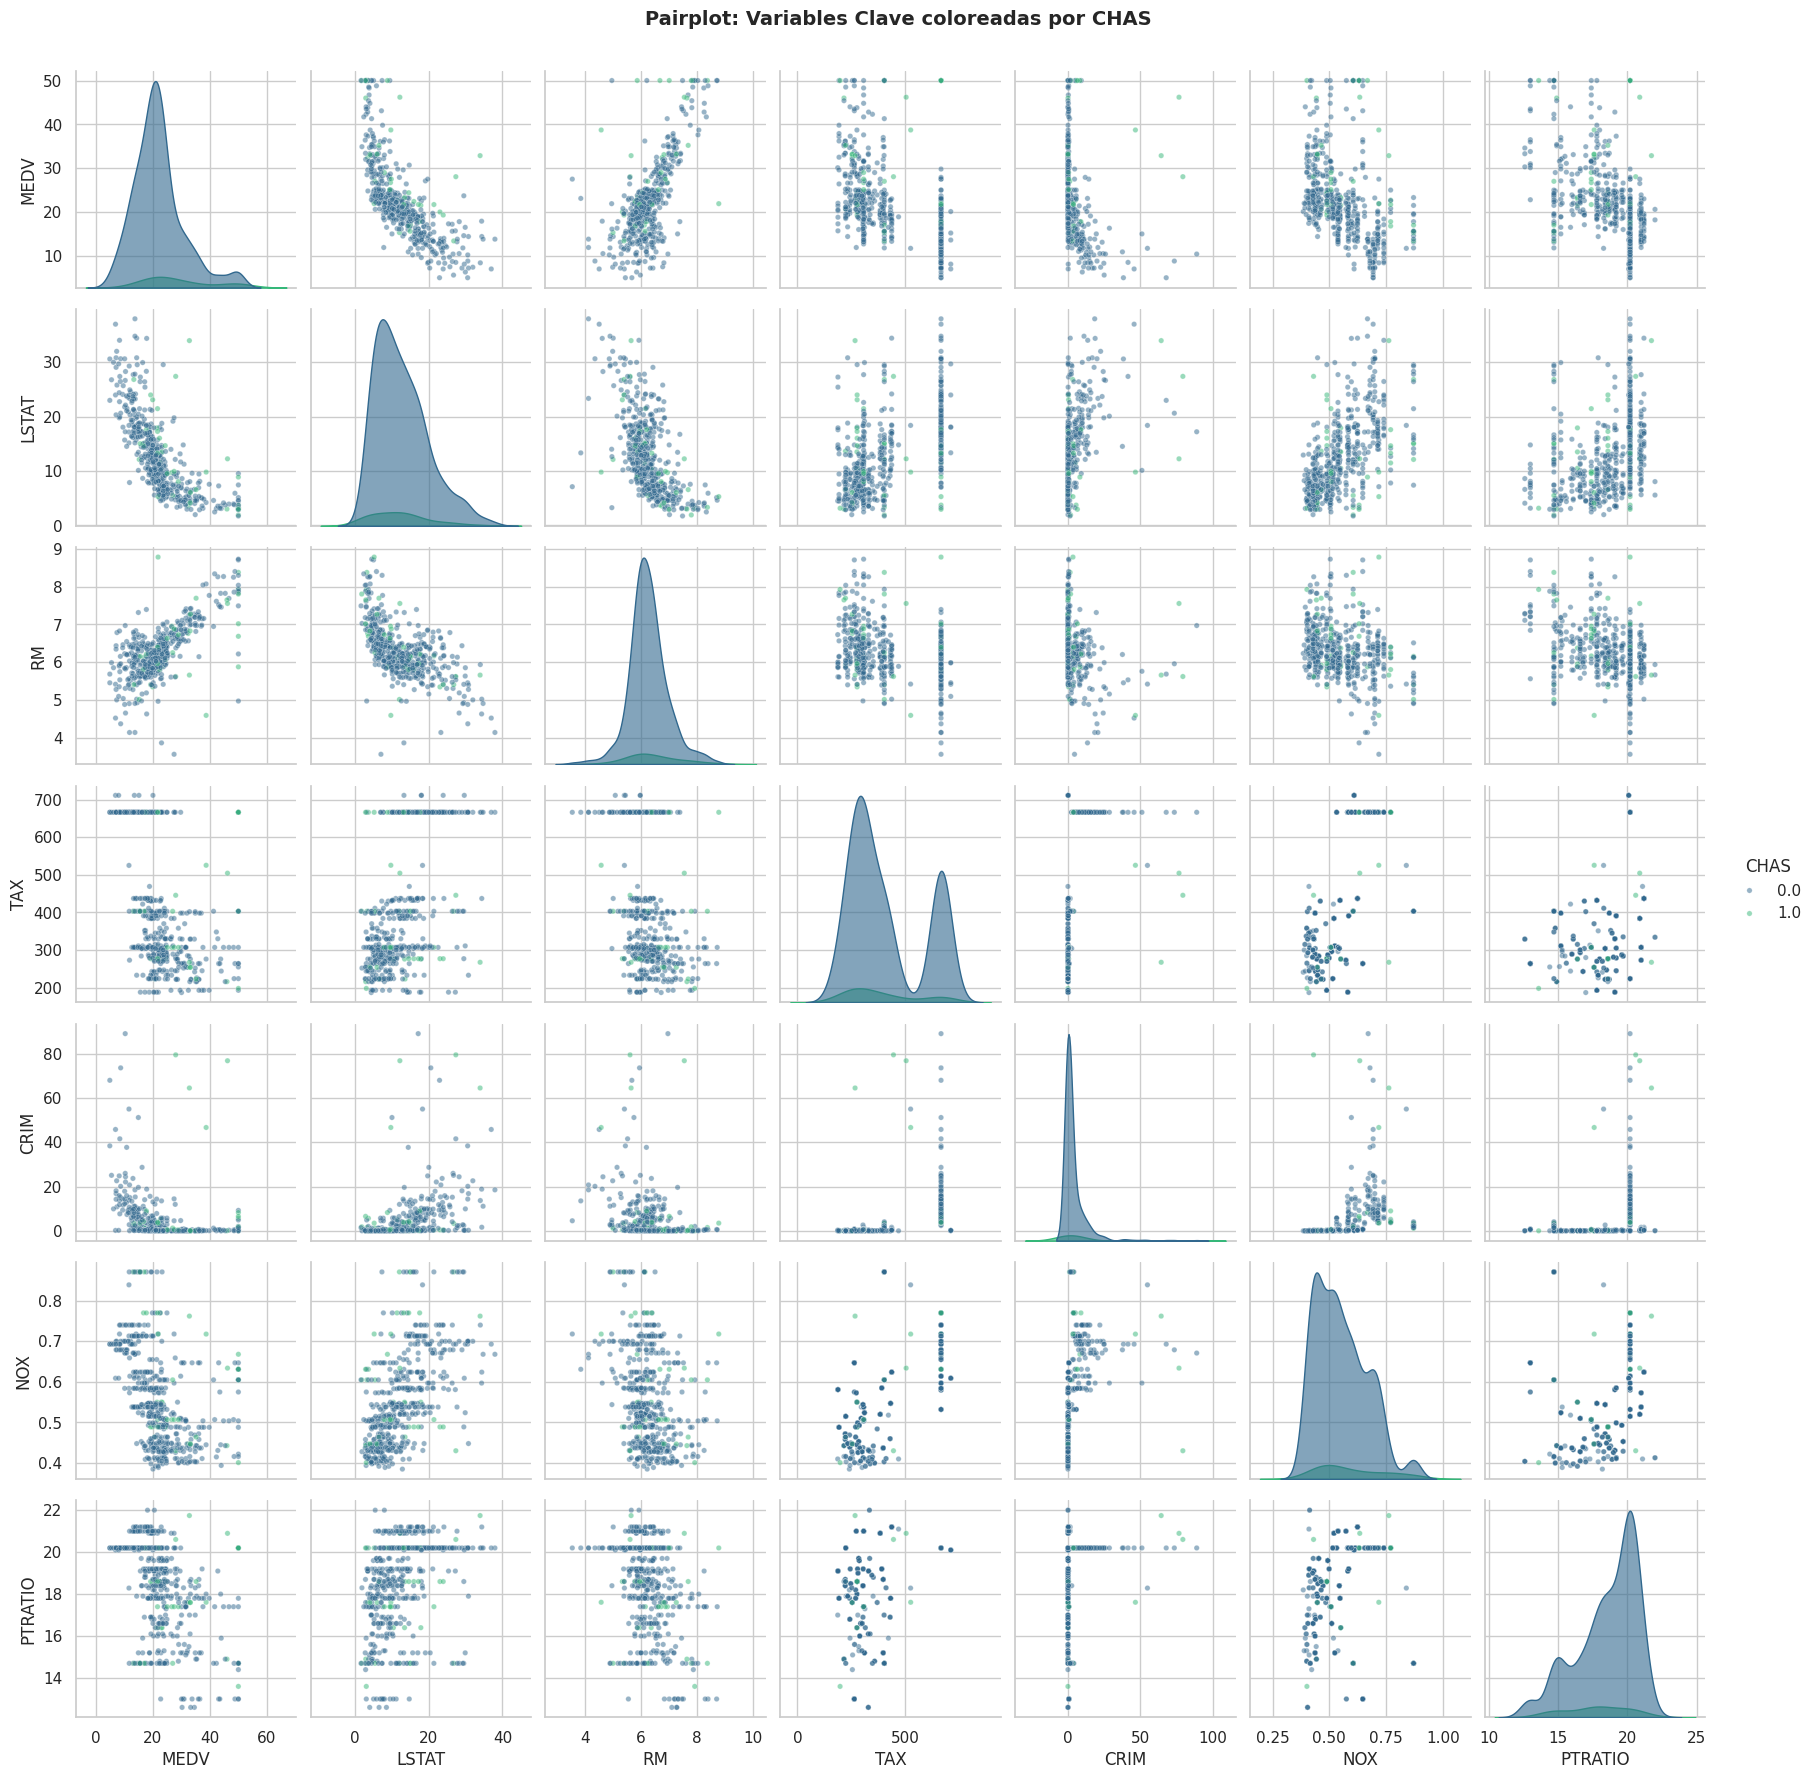

In [ ]:
# Seleccion de variables mas relevantes para visualizacion
vars_pairplot = ['MEDV','LSTAT','RM','TAX','CRIM','NOX','PTRATIO']

g = sns.pairplot(df[vars_pairplot + ['CHAS']].dropna(),
                 hue='CHAS', palette='viridis',
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kws={'alpha': 0.6})
g.figure.suptitle('Pairplot: Variables Clave coloreadas por CHAS',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

Al observar los **scatterplot** observamos que RM y NOX parecen tener una relacion no lineal con MEDV, se las incluira **elevadas al cuadrado como features adicionales**.

`TAX` y `PTRATIO` presentan bimodalidad.

## 1 -5) Inspeccion Datos faltantes


In [ ]:
# Numero de registros con datos faltantes
df.isnull().any(axis=1).sum()

np.int64(48)

In [ ]:
# Primera inspeccion datos faltantes
missing_values = df.isnull().sum()
missing_values = missing_values.to_frame().T
print("Valores faltantes por categoria")
print("="*60)
display(missing_values)

Valores faltantes por categoria


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,23,22,15,23,24,21,24,15,18,28,22,21


Observamos que todas las variables presentan valores faltantes, emplearemos varios criterios para decidir si se inputan o eliminan (registros o variables)

Tipos de datos faltantes a localizar:
*   Registros con valores faltantes en la variable objetivo
*   Registros donde el 50% de las features tengan valores faltantes




In [ ]:
cantidad_nas = df['MEDV'].isna().sum()
print(f'Registros NA en MEDV: {cantidad_nas}')

Registros NA en MEDV: 21


In [ ]:
registros_con_muchos_na = (df.isna().sum(axis=1) > df.shape[1] / 2).sum()

print(f'Registros con más de la mitad de valores NA: {registros_con_muchos_na}')

Registros con más de la mitad de valores NA: 20


Estos registros deberan ser eliminados en el preprocesamiento de datos.
El resto seran inputados.

## 1.6) Pruebas de Normalidad

In [ ]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4694,0.0000,438.7814,0.0000,No
1,ZN,0.5977,0.0000,198.8057,0.0000,No
2,INDUS,0.9085,0.0000,374.1978,0.0000,No
3,NOX,0.9373,0.0000,37.5234,0.0000,No
4,RM,0.9601,0.0000,32.6767,0.0000,No
5,AGE,0.8959,0.0000,155.4211,0.0000,No
6,DIS,0.8987,0.0000,81.2382,0.0000,No
7,TAX,0.8280,0.0000,314.9345,0.0000,No
8,PTRATIO,0.9076,0.0000,46.9050,0.0000,No
9,LSTAT,0.9291,0.0000,64.1694,0.0000,No


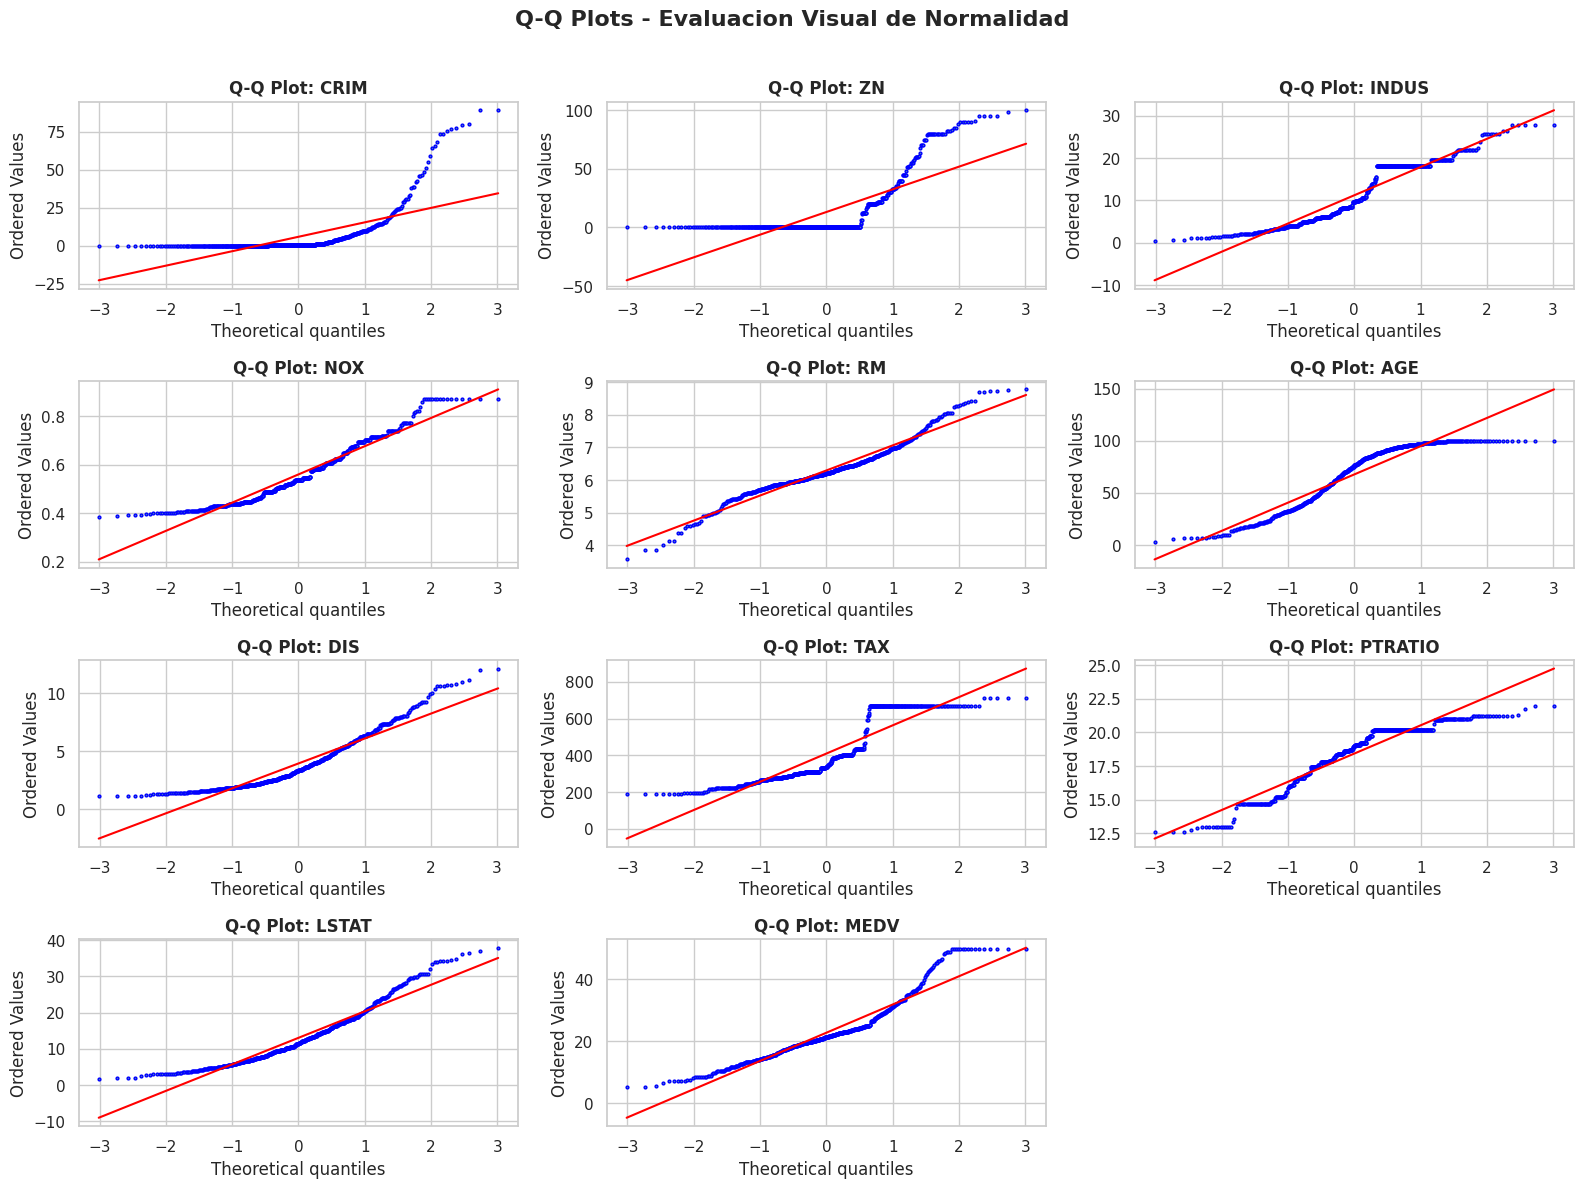

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluacion Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Aunque los Q-Q Plot sugieren que algunas variables podrian seguir una distribucion cercana a la normal, los tests de normalidad muestran que ninguna lo hace. Por lo tanto asumimos que **ninguna variable se distribuye como normal**. Esto sera relevante al momento de seleccionar el metodo de deteccion de outliers (**IQR en lugar de z-score**).

# 2) Validación cruzada

## 2.1 Preprocesamiento y Feature Engineering

Realizamos la division en sets de entranamiento y testeo previo a la inputacion de datos para prevenir el data leakage, es decir, que se contaminen los conjuntos con calculos realizados en la totalidad del dataset.

### 2.1.1) Valores faltantes

Primero eliminaremos los registros donde la variable objetivo este faltando o donde se supere el umbral preestablecido (ver 1-4) de valores faltantes por observacion haya sido superado.

In [ ]:
# 1. Contar el total de registros iniciales
total_inicial = len(df)

# 2. Eliminar registros con NA en la variable objetivo 'MEDV'
nulos_medv = df['MEDV'].isna().sum()
df_clean_1 = df.dropna(subset=['MEDV'])

# 3. Eliminar registros con más del 50% de las variables faltantes
# Calculamos cuántas columnas tiene el DataFrame
umbral_columnas = df.shape[1] / 2
# Identificamos las filas que superan ese umbral de nulos
filas_con_muchos_na = df_clean_1.isna().sum(axis=1) > umbral_columnas
cantidad_filas_muchos_na = filas_con_muchos_na.sum()

# Filtramos para quedarnos solo con las filas que NO superan el 50% de nulos
df_clean_1 = df_clean_1[~filas_con_muchos_na]

# 4. Imprimir el reporte de registros eliminados
print(f'Registros eliminados por tener NA en MEDV: {nulos_medv}')
print(
    'Registros eliminados por tener más del 50% de features faltantes:'
    f' {cantidad_filas_muchos_na}'
)
print(f'Total de registros finales en el DataFrame: {len(df_clean_1)}')

Registros eliminados por tener NA en MEDV: 21
Registros eliminados por tener más del 50% de features faltantes: 4
Total de registros finales en el DataFrame: 531


Observacion: Gran cantidad de los registros con mas del 50% de features faltantes se eliminaron en el primer paso. Por eso la divergencia con el analisis en 1.5

In [ ]:
# Inspeccion datos faltantes tras limpieza de registros
missing_values = df_clean_1.isnull().sum()
missing_values = missing_values.to_frame().T
print("Valores faltantes por categoria")
print("="*60)
display(missing_values)

Valores faltantes por categoria


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,7,9,1,6,6,4,9,3,7,7,6,0


###2.2.2) Variables adicionales

Se incorporan variables al cuadrado para incluir posibles no linealidades.

In [ ]:
df_clean_1['RM_sq'] = df_clean_1['RM'] ** 2
df_clean_1['NOX_sq'] = df_clean_1['NOX'] ** 2


Aplicamos logaritmo a las variables con distribucion unimodal con alto sesgo positivo creando nuevas Features y comparamos con variables originales

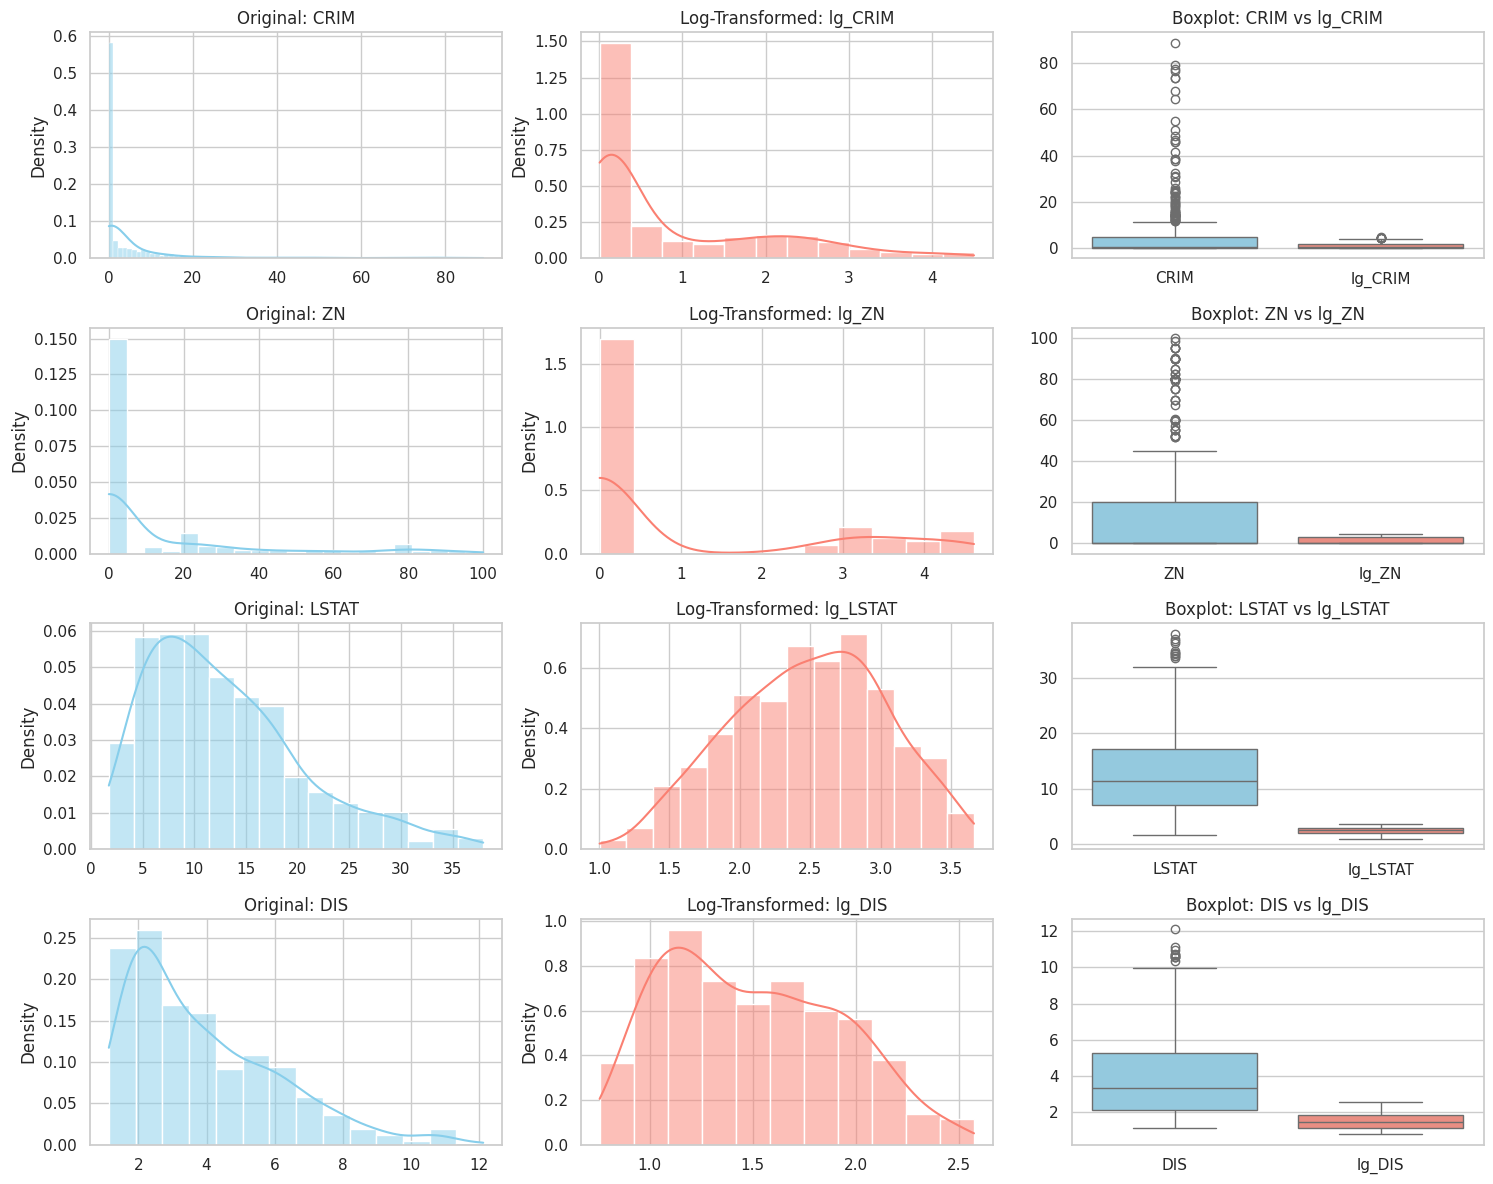

In [ ]:
features_log = ['CRIM', 'ZN', 'LSTAT', 'DIS',]

# Configurar el tamaño de la figura dinámicamente según el número de variables (3 columnas)
plt.figure(figsize=(15, len(features_log) * 3))

for i, col in enumerate(features_log):
  # 1. Aplicar la transformación logarítmica
  df_clean_1[f'lg_{col}'] = np.log1p(df_clean_1[col])

  # 2. Gráfico 1: Histograma de la variable original (Columna 1)
  plt.subplot(len(features_log), 3, 3 * i + 1)
  sns.histplot(df_clean_1[col], kde=True, color='skyblue', stat='density')
  plt.title(f'Original: {col}')
  plt.xlabel('')

  # 3. Gráfico 2: Histograma de la variable transformada (Columna 2)
  plt.subplot(len(features_log), 3, 3 * i + 2)
  sns.histplot(
      df_clean_1[f'lg_{col}'], kde=True, color='salmon', stat='density'
  )
  plt.title(f'Log-Transformed: lg_{col}')
  plt.xlabel('')

  # 4. Gráfico 3: Boxplots comparativos antes y después (Columna 3)
  plt.subplot(len(features_log), 3, 3 * i + 3)
  sns.boxplot(
      data=df_clean_1[[col, f'lg_{col}']], palette=['skyblue', 'salmon']
  )
  plt.title(f'Boxplot: {col} vs lg_{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

`LSTAT` y `DIS` son buenas candidatas para aplicar transformación logarítmica.La dispersión se vuelve mucho más simétrica y desaparecen los outliers.

Al aplicar logaritmo a `ZN` el grafico colapsa deformandose la distribución. Con `CRIM` ocurre algo similar.

Conclusion: Utilizar `lg_LSTAT` y `lg_DIS` en reemplazo de las variables originales para el modelo de regresion lineal mejorado.


Aplicamos exponenciacion a las variables con distribucion unimodal con alto sesgo negativo creando nuevas Features:

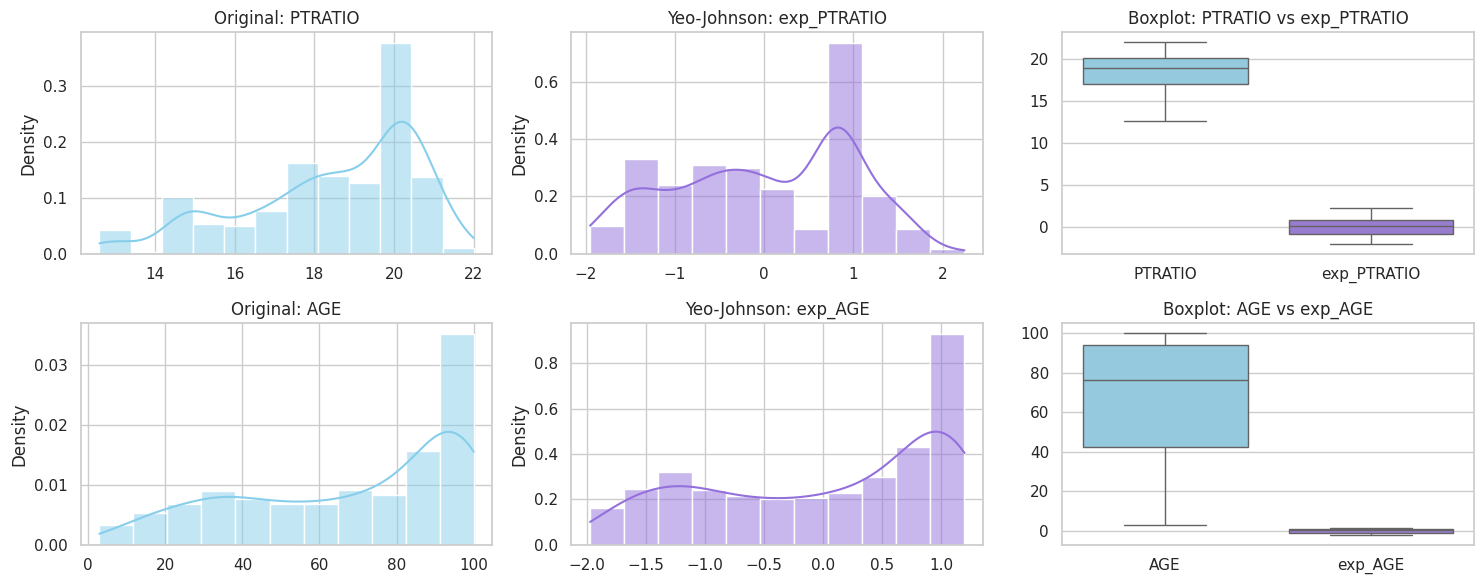

In [ ]:
features_yeo = [ 'PTRATIO', 'AGE']

# Instanciar el PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

# Configurar el tamaño de la figura para alojar las 3 columnas
plt.figure(figsize=(15, len(features_yeo) * 3))

for i, col in enumerate(features_yeo):
  # 1. Aplicar la transformación Yeo-Johnson
  df_clean_1[f'exp_{col}'] = pt.fit_transform(df_clean_1[[col]]).ravel()

  # 2. Gráfico 1: Histograma de la variable original (Columna 1)
  plt.subplot(len(features_yeo), 3, 3 * i + 1)
  sns.histplot(df_clean_1[col], kde=True, color='skyblue', stat='density')
  plt.title(f'Original: {col}')
  plt.xlabel('')

  # 3. Gráfico 2: Histograma de la variable transformada (Columna 2)
  plt.subplot(len(features_yeo), 3, 3 * i + 2)
  sns.histplot(
      df_clean_1[f'exp_{col}'], kde=True, color='mediumpurple', stat='density'
  )
  plt.title(f'Yeo-Johnson: exp_{col}')
  plt.xlabel('')

  # 4. Gráfico 3: Boxplots comparativos antes y después (Columna 3)
  plt.subplot(len(features_yeo), 3, 3 * i + 3)
  sns.boxplot(
      data=df_clean_1[[col, f'exp_{col}']], palette=['skyblue', 'mediumpurple']
  )
  plt.title(f'Boxplot: {col} vs exp_{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

Puede observarse visualmente que no se logra aproximar la distribucion a la normal. No se emplearan estas transformaciones.

Aplicamos logaritmo a la variable objetivo creando nueva feature

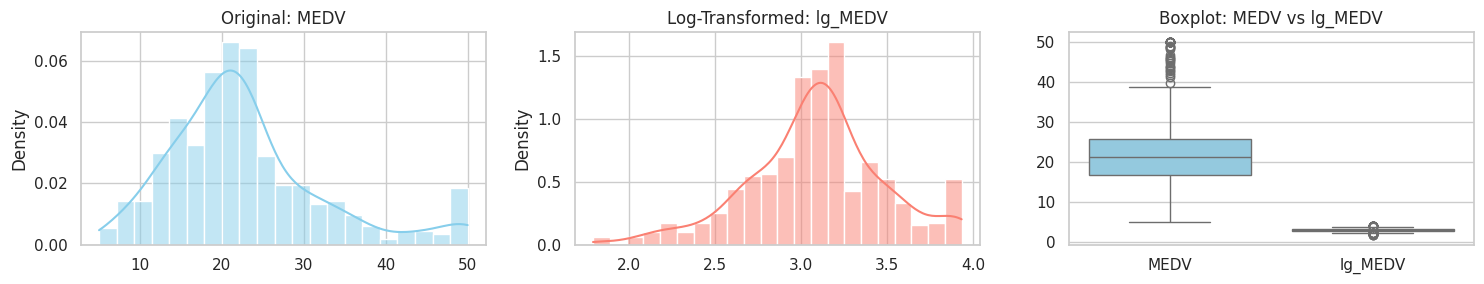

In [ ]:
target_log = ['MEDV']

# Configurar el tamaño de la figura dinámicamente según el número de variables (3 columnas)
plt.figure(figsize=(15, len(target_log) * 3))

for i, col in enumerate(target_log):
  # 1. Aplicar la transformación logarítmica
  df_clean_1[f'lg_{col}'] = np.log1p(df_clean_1[col])

  # 2. Gráfico 1: Histograma de la variable original (Columna 1)
  plt.subplot(len(target_log), 3, 3 * i + 1)
  sns.histplot(df_clean_1[col], kde=True, color='skyblue', stat='density')
  plt.title(f'Original: {col}')
  plt.xlabel('')

  # 3. Gráfico 2: Histograma de la variable transformada (Columna 2)
  plt.subplot(len(target_log), 3, 3 * i + 2)
  sns.histplot(
      df_clean_1[f'lg_{col}'], kde=True, color='salmon', stat='density'
  )
  plt.title(f'Log-Transformed: lg_{col}')
  plt.xlabel('')

  # 4. Gráfico 3: Boxplots comparativos antes y después (Columna 3)
  plt.subplot(len(target_log), 3, 3 * i + 3)
  sns.boxplot(
      data=df_clean_1[[col, f'lg_{col}']], palette=['skyblue', 'salmon']
  )
  plt.title(f'Boxplot: {col} vs lg_{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

Conservaremos esta transformacion en caso de encontrarnos con Heterocedasticidad en el modelo

### 2.2.3)  Transformacion de tipo de variables

#### 2.2.3.1) Binning

In [ ]:
# ZN: 1 si tiene terreno residencial (> 0), 0 si no tiene (la gran mayoría)
df_clean_1['bin_ZN'] = (df_clean_1['ZN'] > 0).astype(int)

# CRIM: Definimos un umbral de alerta (ej. el percentil 90) para marcar alta criminalidad
threshold_crim = df_clean_1['CRIM'].quantile(0.90)
df_clean_1['bin_CRIM'] = (df_clean_1['CRIM'] > threshold_crim).astype(int)

#### 2.2.3.2) Discretizacion

In [ ]:
# AGE: Discretización por rangos lógicos de antigüedad (porcentaje de casas construidas antes de 1940)
bins_age = [0, 35, 70, 100]
labels_age = ['Baja_antiguedad', 'Media_antiguedad', 'Alta_antiguedad']
df_clean_1['disc_AGE'] = pd.cut(
    df_clean_1['AGE'], bins=bins_age, labels=labels_age, include_lowest=True
)


#### 2-2-3-3) Comparaciones

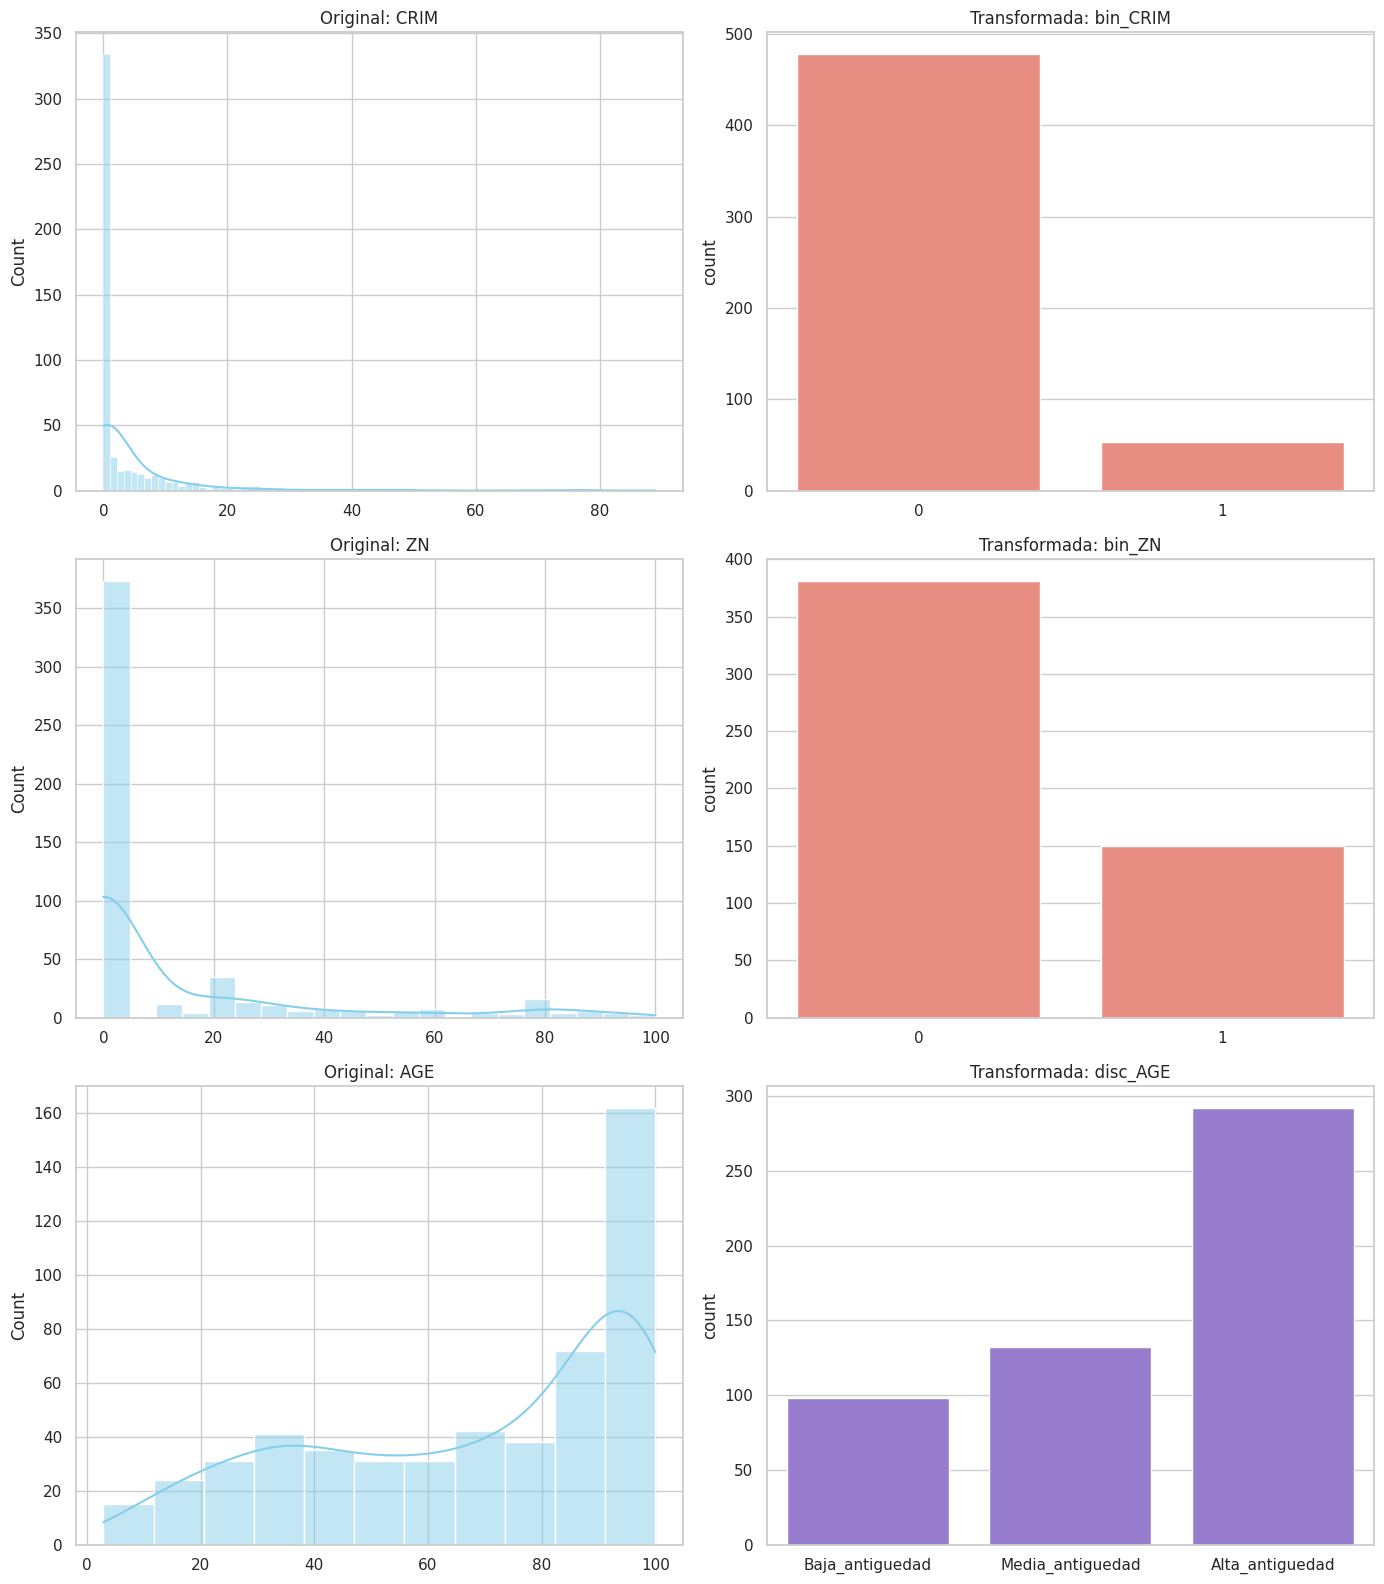

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

pares = [
    ('CRIM', 'bin_CRIM', 'skyblue', 'salmon', 'CRIM (Original vs Binarizada)'),
    ('ZN', 'bin_ZN', 'skyblue', 'salmon', 'ZN (Original vs Binarizada)'),
    (
        'AGE',
        'disc_AGE',
        'skyblue',
        'mediumpurple',
        'AGE (Original vs Discretizada)',
    ),

]

for i, (orig, trans, color_orig, color_trans, titulo) in enumerate(pares):
  # Columna Izquierda: Variable Original (Continuo)
  sns.histplot(df_clean_1[orig], kde=True, ax=axes[i, 0], color=color_orig)
  axes[i, 0].set_title(f'Original: {orig}')
  axes[i, 0].set_xlabel('')

  # Columna Derecha: Variable Transformada (Binaria o Discreta)
  sns.countplot(x=df_clean_1[trans], ax=axes[i, 1], color=color_trans)
  axes[i, 1].set_title(f'Transformada: {trans}')
  axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

#### 2.2.3.4) One Hot Encoding

In [ ]:
df_clean_1 = pd.get_dummies(df_clean_1, columns=['disc_AGE'], drop_first=True, dtype=int)

In [ ]:
df_clean_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 531 entries, 0 to 555
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   CRIM                       524 non-null    float64 
 1   ZN                         522 non-null    float64 
 2   INDUS                      530 non-null    float64 
 3   CHAS                       525 non-null    category
 4   NOX                        525 non-null    float64 
 5   RM                         527 non-null    float64 
 6   AGE                        522 non-null    float64 
 7   DIS                        528 non-null    float64 
 8   TAX                        524 non-null    float64 
 9   PTRATIO                    524 non-null    float64 
 10  LSTAT                      525 non-null    float64 
 11  MEDV                       531 non-null    float64 
 12  RM_sq                      527 non-null    float64 
 13  NOX_sq                     525 non-null 

Consideramos de la variable disc_AGE, el valor "baja" como nivel

In [ ]:
df_clean_1.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV', 'RM_sq', 'NOX_sq', 'lg_CRIM', 'lg_ZN',
       'lg_LSTAT', 'lg_DIS', 'exp_PTRATIO', 'exp_AGE', 'lg_MEDV', 'bin_ZN',
       'bin_CRIM', 'disc_AGE_Media_antiguedad', 'disc_AGE_Alta_antiguedad'],
      dtype='object')

## 2.2) Division Train-Test

In [ ]:
#Division train - test

features_seleccionadas = ['bin_CRIM', #Esta
                          'bin_ZN', #Esta
                          'INDUS',
                          'CHAS',
                          'NOX',
                          'NOX_sq',
                          'RM',
                          'RM_sq',
                          'disc_AGE_Media_antiguedad', #Esta
                          'disc_AGE_Alta_antiguedad', #Esta
                          'lg_DIS',
                          'TAX',
                          'PTRATIO',
                          'lg_LSTAT']



variable_objetivo = ['MEDV']



X = df_clean_1[features_seleccionadas]
y = df_clean_1[variable_objetivo]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 42)




# 3) Inputación y tratamiento

## 3.1) Deteccion y tratamiento de outliers features

Se realiza previo al tratamiento de datos faltantes para no arrastrar el valor artificial que sesgue el calculo de las medidas utilizadas para inputar. Ademas se busca preservar la naturaleza de los datos.

Como en 1.6 detectamos que las variables no se distribuyen como una normal, aplicaremos el metodo IQR para la deteccion de los outliers en el conjunto de entrenamiento.

In [ ]:
#Deteccion
cols_filtrar = [col for col in X_train.columns if col not in ['CHAS','bin_CRIM','bin_ZN','disc_AGE_Media_antiguedad','disc_AGE_Alta_antiguedad']] # No filtramos en columnas categóricas

# Fijamos los límites dentro del conjunto de entrenamiento solamente (evitar Data Leakage)
Q1 = X_train[cols_filtrar].quantile(0.25)
Q3 = X_train[cols_filtrar].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# EVALUACIÓN EN TRAIN (sin modificar el dataset original)
outliers_train_mask = (X_train[cols_filtrar] < limite_inferior) | (X_train[cols_filtrar] > limite_superior)
outliers_train_count = outliers_train_mask.sum()

#Creamos tabla diagnostico

tabla_outliers_train = pd.DataFrame({
    'Outliers_Detectados': outliers_train_count,
    'Porcentaje_%': ((outliers_train_count / len(X_train)) * 100).round(2)
})
tabla_outliers_train = tabla_outliers_train.sort_values(by='Outliers_Detectados', ascending=False)

print('Outliers detectados TRAIN')
print('=' * 50)
display(tabla_outliers_train)


# EVALUACIÓN EN TEST (usando los límites calculados en train como verdaderos)
outliers_test_mask = (X_test[cols_filtrar] < limite_inferior) | (X_test[cols_filtrar] > limite_superior)
outliers_test_count = outliers_test_mask.sum()

#Creamos tabla diagnostico

tabla_outliers_test = pd.DataFrame({
    'Outliers_Detectados': outliers_test_count,
    'Porcentaje_%': ((outliers_test_count / len(X_test)) * 100).round(2)
})
tabla_outliers_test = tabla_outliers_test.sort_values(by='Outliers_Detectados', ascending=False)

print('\nOutliers detectados TEST')
print('=' * 50)
display(tabla_outliers_test)

Outliers detectados TRAIN


,Outliers_Detectados,Porcentaje_%
RM,32,7.5500
RM_sq,30,7.0800
NOX_sq,15,3.5400
INDUS,0,0.0000
NOX,0,0.0000
lg_DIS,0,0.0000
TAX,0,0.0000
PTRATIO,0,0.0000
lg_LSTAT,0,0.0000



Outliers detectados TEST


,Outliers_Detectados,Porcentaje_%
RM_sq,10,9.3500
RM,10,9.3500
NOX_sq,2,1.8700
INDUS,0,0.0000
NOX,0,0.0000
lg_DIS,0,0.0000
TAX,0,0.0000
PTRATIO,0,0.0000
lg_LSTAT,0,0.0000


In [ ]:
#Tratamiento

cols_filtrar = [col for col in X_train.columns if col not in ['CHAS','bin_CRIM','bin_ZN','disc_AGE_Media_antiguedad','disc_AGE_Alta_antiguedad']]#No filtramos en columnas categoricas
#Fijamos los limites dentro del conjunto de entrenamiento solamente, evitando el Data Leakage
Q1 = X_train[cols_filtrar].quantile(0.25)
Q3 = X_train[cols_filtrar].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
# Creamos nueva variable para filtrar y aplicamos los limites determinados previamente
X_train_clean = X_train.copy()
mascara_train = (X_train[cols_filtrar] >= limite_inferior) & (X_train[cols_filtrar] <= limite_superior)
X_train_clean[cols_filtrar] = X_train[cols_filtrar].where(mascara_train)

#Aplicamos el mismo procedimiento para los datos de Testing (con los limites calculados para los datos de entrenamiento como rango aceptable)

X_test_clean = X_test.copy()
mascara_test = (X_test[cols_filtrar] >= limite_inferior) & (X_test[cols_filtrar] <= limite_superior)
X_test_clean[cols_filtrar] = X_test[cols_filtrar].where(mascara_test)



### 3.1.1) Comparación Antes y Despues

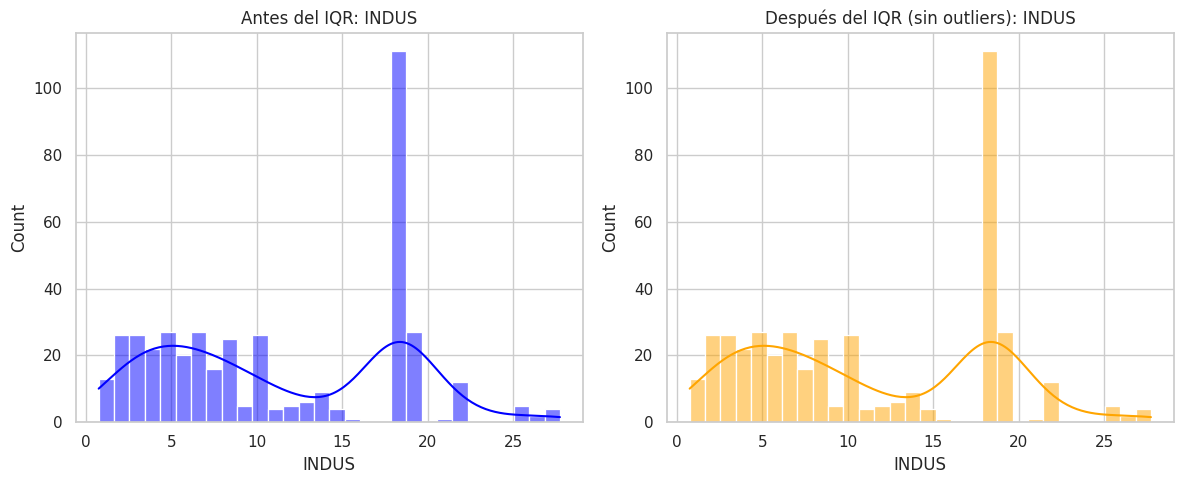

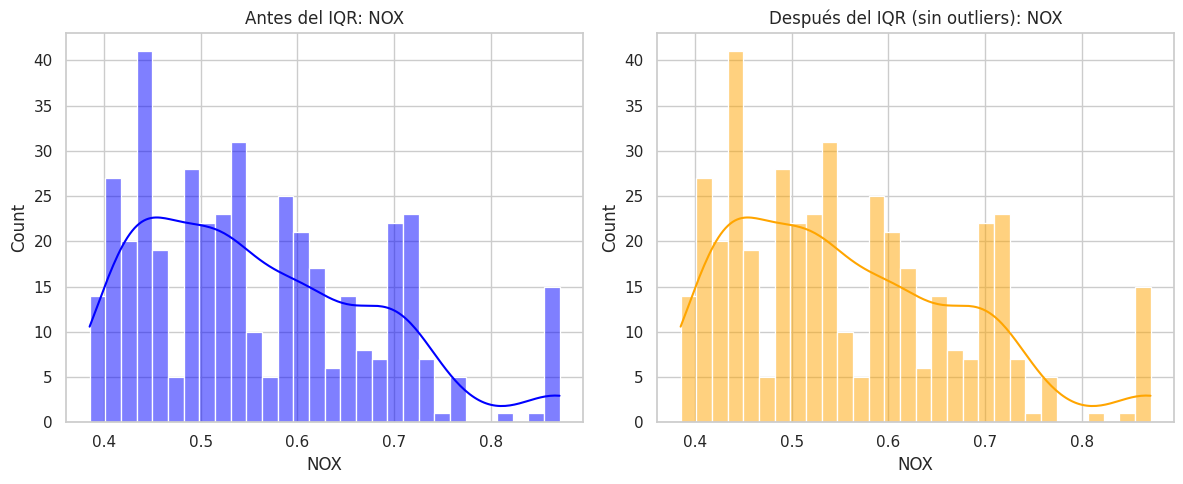

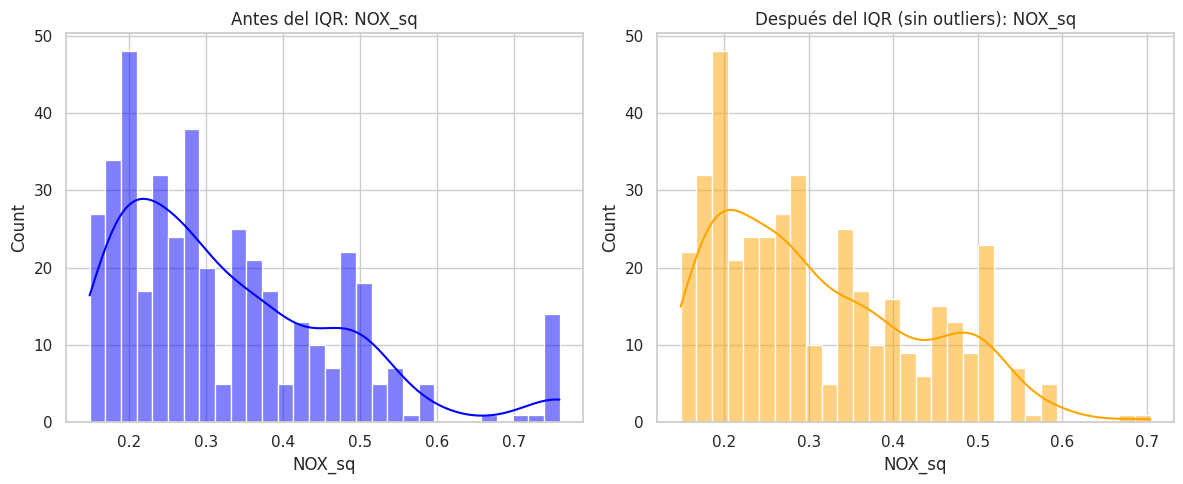

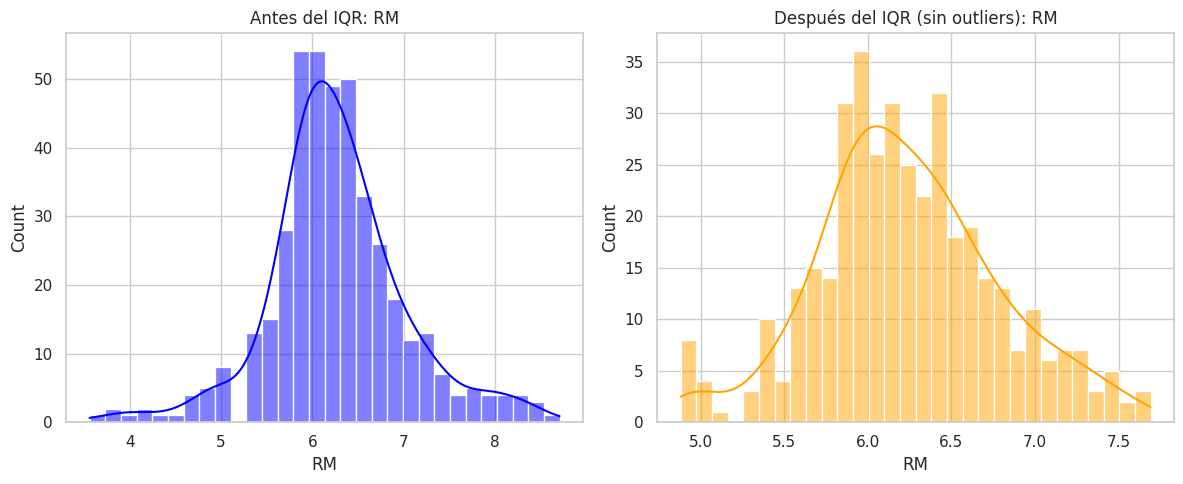

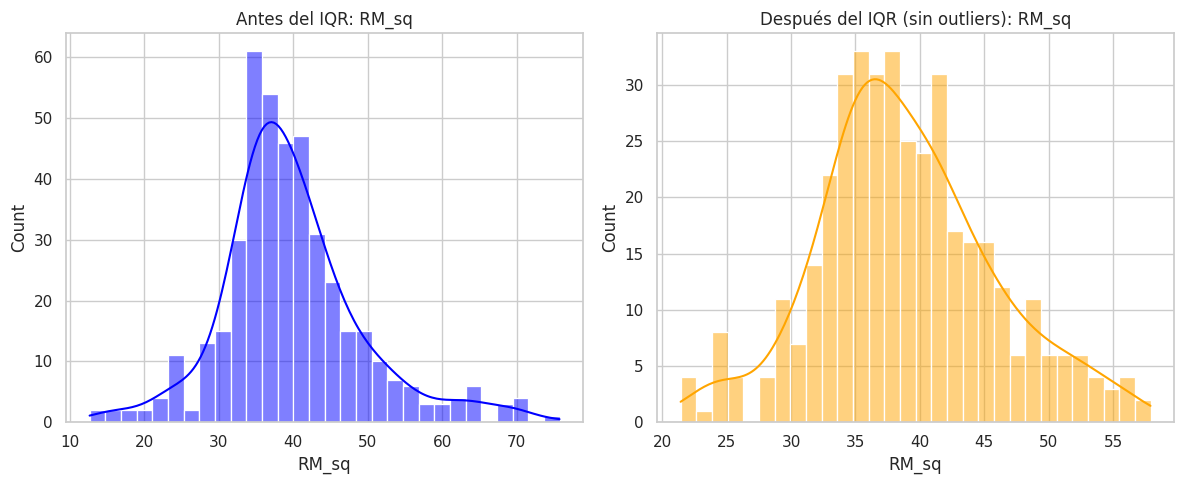

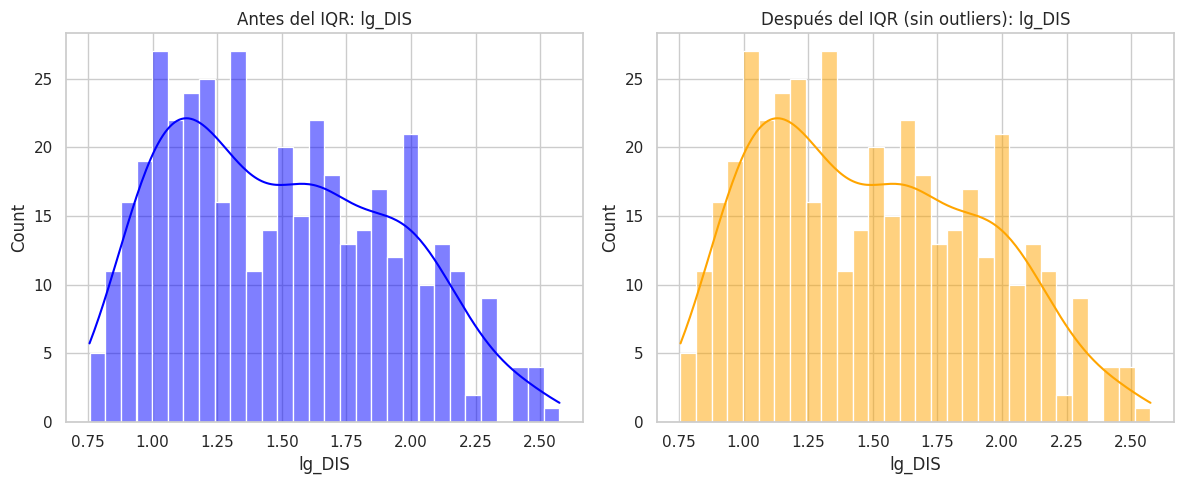

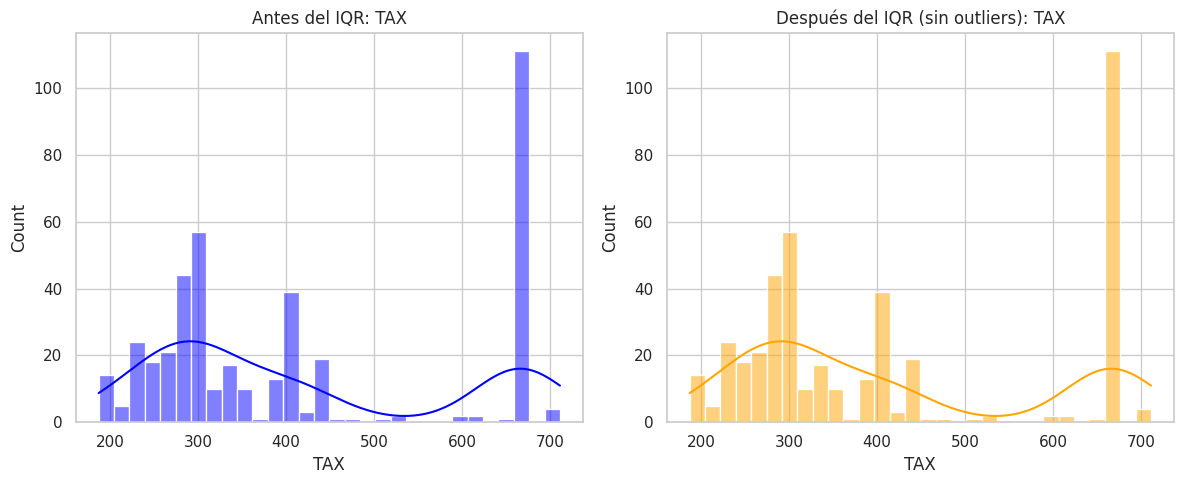

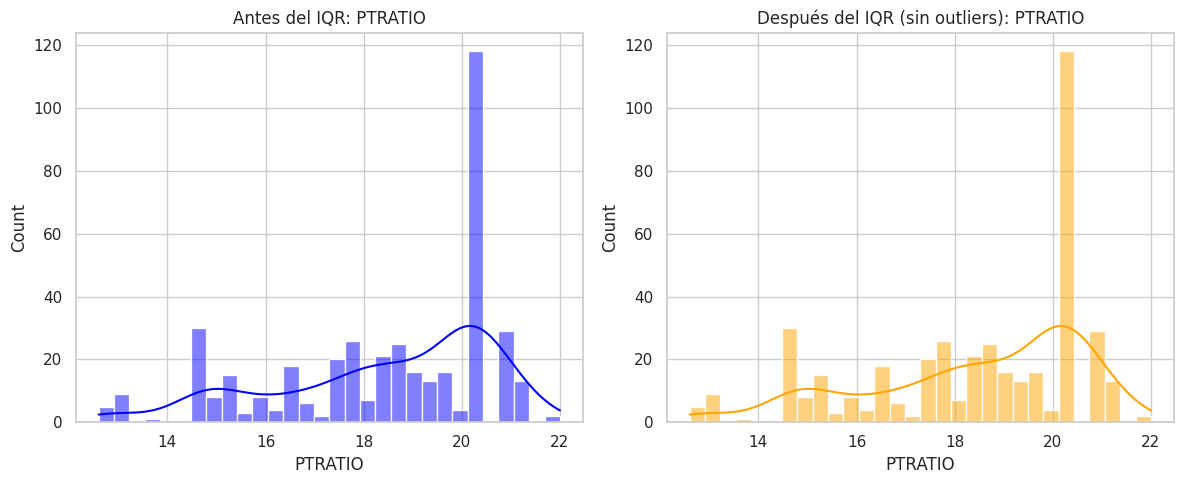

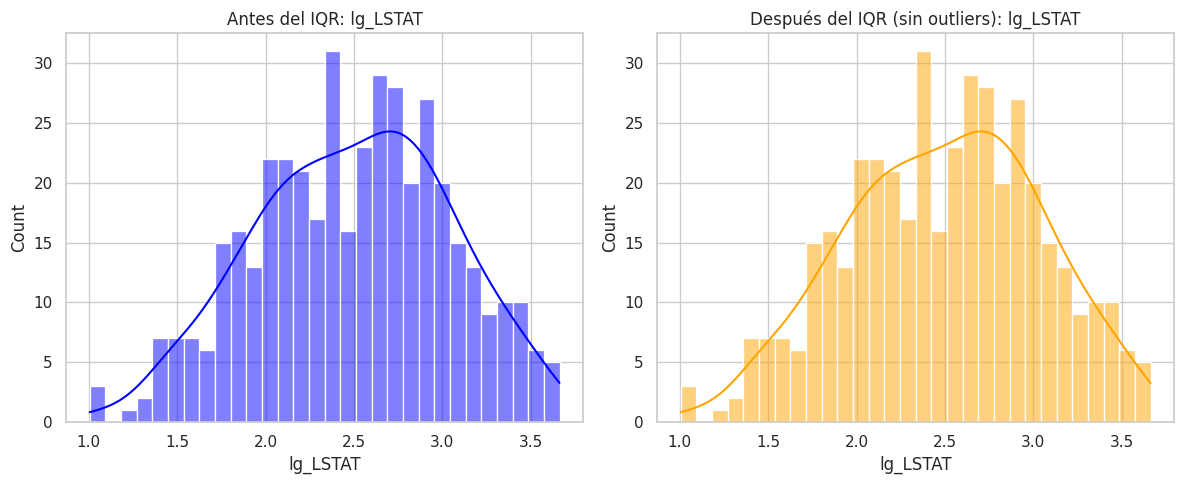

,Original_Media,Tratado_Media,Original_Mediana,Tratado_Mediana,Original_Std,Tratado_Std
Columna,,,,,,
INDUS,11.3228,11.3228,9.9000,9.9000,6.9351,6.9351
NOX,0.5581,0.5581,0.5380,0.5380,0.1187,0.1187
NOX_sq,0.3256,0.3095,0.2894,0.2830,0.1434,0.1188
RM,6.2668,6.2339,6.1985,6.1850,0.7453,0.5420
RM_sq,39.8265,38.8774,38.4214,38.1306,9.4750,6.8722
lg_DIS,1.4961,1.4961,1.4660,1.4660,0.4277,0.4277
TAX,414.7741,414.7741,344.5125,344.5125,169.8265,169.8265
PTRATIO,18.3924,18.3924,18.9000,18.9000,2.2220,2.2220
lg_LSTAT,2.4946,2.4946,2.5217,2.5217,0.5468,0.5468


In [ ]:
# 1. Define la lista con las columnas que deseas inspeccionar
columnas_a_revisar = [col for col in X_train_clean.columns if col not in ['CHAS','bin_CRIM','bin_ZN','disc_AGE_Media_antiguedad','disc_AGE_Alta_antiguedad']]

# 2. Itera sobre cada columna generando sus gráficos
for columna in columnas_a_revisar:
    plt.figure(figsize=(12, 5))

    # Distribución ANTES del tratamiento
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[columna], kde=True, color='blue', bins=30)
    plt.title(f'Antes del IQR: {columna}')

    # Distribución DESPUÉS (sin outliers)
    plt.subplot(1, 2, 2)
    sns.histplot(X_train_clean[columna].dropna(), kde=True, color='orange', bins=30)
    plt.title(f'Después del IQR (sin outliers): {columna}')

    plt.tight_layout()
    plt.show()

    resultados = []

for columna in columnas_a_revisar:
    resumen = {
        'Columna': columna,
        'Original_Media': X_train[columna].mean(),
        'Tratado_Media': X_train_clean[columna].mean(),
        'Original_Mediana': X_train[columna].median(),
        'Tratado_Mediana': X_train_clean[columna].median(),
        'Original_Std': X_train[columna].std(),
        'Tratado_Std': X_train_clean[columna].std()
    }
    resultados.append(resumen)

# 3. Crea el DataFrame final y asígnale la columna 'Columna' como índice
resumen_comparativo_total = pd.DataFrame(resultados).set_index('Columna')

# Muestra la tabla completa
display(resumen_comparativo_total)

La mediana debe permanecer estable y el desvio estandar debe disminuir. Concluimos que las transformaciones no han sido distorsivas respecto a las distribuciones subyacentes.

##3.2) Inspeccion outliers variable objetivo

          MEDV
0.0100  7.0460
0.0500  9.9167
0.1000 12.5600
0.9000 35.1700
0.9500 43.7550
0.9900 50.0000
Mínimo: MEDV   5.0000
dtype: float64 | Máximo: MEDV   50.0000
dtype: float64


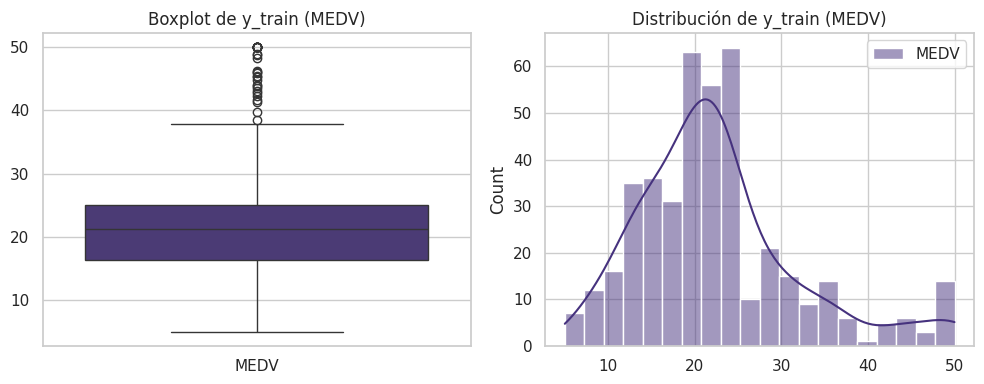

In [ ]:
print(y_train.quantile([0.01, 0.05, 0.10, 0.90, 0.95, 0.99]))
print("Mínimo:", y_train.min(), "| Máximo:", y_train.max())


plt.figure(figsize=(10, 4))

# Gráfico 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=y_train)  # <-- Acá cambiamos 'y=' por 'data='
plt.title("Boxplot de y_train (MEDV)")

# Gráfico 2: Histograma
plt.subplot(1, 2, 2)
sns.histplot(y_train, kde=True)
plt.title("Distribución de y_train (MEDV)")

plt.tight_layout()
plt.show()

No se realizara inputacion a la variable objetivo.

# 4) Soluciones de regresion lineal multiple

## 4.1) Linear Regression

Para evitar realizar escalados incorrectos, escalamos unicamente las variables numericas y tambien modificamos el inputador para que funcione con las excepciones del scaler.

In [ ]:
columnas_numericas = ['INDUS','NOX','NOX_sq','RM','RM_sq', 'lg_DIS','TAX','PTRATIO','lg_LSTAT']
#Crear el transformador de columnas para el scaler
scaler_con_excepciones = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), columnas_numericas)
    ],
    remainder='passthrough'  # Las demás columnas no se tocan
)

imputador_df = SimpleImputer(strategy='median').set_output(transform='pandas')


------

In [ ]:

#Definir el preprocesador común (Imputador + Scaler con excepciones)
preprocesador = Pipeline([
    ('imputer', imputador_df),
    ('scaler_excepciones', scaler_con_excepciones)
])





In [ ]:
pipeline_modelo_Linear_Regression = Pipeline([
    ('preprocesador', preprocesador),
    ('regressor', LinearRegression())
])

pipeline_modelo_Linear_Regression.fit(X_train_clean, y_train)



Pipeline(steps=[('preprocesador',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler_excepciones',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('standard',
                                                                   StandardScaler(),
                                                                   ['INDUS',
                                                                    'NOX',
                                                                    'NOX_sq',
                                                                    'RM',
                                                                    'RM_sq',
                                                                    'lg_DIS',
                                                                    'TAX',
                                                                    'PTRATIO',
                                                                    'lg_LSTAT'])]))])),
                ('regressor', LinearRegression())])

------

In [ ]:
# Generamos predicciones para ambos conjuntos
y_pred_train = pipeline_modelo_Linear_Regression.predict(X_train_clean)
y_pred_test = pipeline_modelo_Linear_Regression.predict(X_test_clean)

#Calcular las métricas
def calcular_metricas(y_real, y_pred, nombre_conjunto):
    return {
        'Conjunto': nombre_conjunto,
        'R² Score': r2_score(y_real, y_pred),
        'MSE': mean_squared_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

# Calcular métricas para train y test
metricas_train = calcular_metricas(y_train, y_pred_train, 'Entrenamiento (Train)')
metricas_test = calcular_metricas(y_test, y_pred_test, 'Prueba (Test)')

# Crear tabla comparativa
df_comparacion = pd.DataFrame([metricas_train, metricas_test])
df_comparacion.set_index('Conjunto', inplace=True)

display(df_comparacion)

,R² Score,MSE,RMSE,MAE
Conjunto,,,,
Entrenamiento (Train),0.6632,29.3738,5.4198,3.7333
Prueba (Test),0.6239,36.4695,6.0390,4.0622


## 4.2) Gradient Descent

### 4.2.1) Funciones proporcionadas por la catedra

In [ ]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    La función ajusta los pesos W de un modelo lineal de la forma:
        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Parámetros
    ----------
    X_train :
      np.ndarray Matriz de características de entrenamiento de dimensiones (n, m), donde n es la cantidad de muestras y m la cantidad de variables.
    y_train :
      np.ndarray Vector de valores objetivo de entrenamiento de dimensiones (n, 1).
    X_val :
      np.ndarray Matriz de características de validación de dimensiones (p, m), donde p es la cantidad de muestras de validación.
    y_val :
      np.ndarray Vector de valores objetivo de validación de dimensiones (p, 1).
    lr :
      float, optional Tasa de aprendizaje utilizada para actualizar los pesos. Por defecto es 0.01.
    epochs :
      int, optional Cantidad de iteraciones del algoritmo de Gradient Descent. Por defecto es 100.

    Retorna
    -------
    np.ndarray Vector de pesos W de dimensiones (m + 1, 1), incluyendo el término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_val para representar el término independiente (bias).
    2. Se inicializan aleatoriamente los pesos W.
    3. En cada época:
      - Se calcula la predicción sobre el conjunto de entrenamiento.
      - Se calcula el MSE de entrenamiento.
      - Se calcula la predicción sobre el conjunto de validación.
      - Se calcula el MSE de validación.
      - Se calcula el gradiente de la función de costo respecto de W.
      - Se actualizan los pesos utilizando la regla de Gradient Descent: W = W - lr * gradient
      4. Finalmente, se grafica la evolución del MSE de entrenamiento y validación a lo largo de las épocas.
        El gradiente utilizado corresponde a: ∇J(W) = -(2 / n) X.T (y - XW) donde J(W) es el Error Cuadrático Medio.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [ ]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Stochastic Gradient Descent (SGD).

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    A diferencia de Gradient Descent tradicional, que calcula el gradiente
    utilizando todas las muestras antes de actualizar los pesos, SGD actualiza
    los pesos después de procesar cada muestra individual.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todas las muestras de entrenamiento. Por defecto es 100.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se permutan aleatoriamente las muestras de entrenamiento
      para evitar que el orden de los datos afecte al proceso de aprendizaje.

    4. Para cada muestra de entrenamiento:
      - Se calcula la predicción.
      - Se calcula el error entre el valor real y la predicción.
      - Se calcula el error cuadrático de esa muestra.
      - Se calcula el gradiente respecto de los pesos.
      - Se actualizan inmediatamente los pesos.

    5. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para observar la evolución del modelo.

    El gradiente utilizado para una muestra individual es:

        ∇J(W) = -2 * x_i.T * (y_i - x_i @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de Gradient Descent tradicional es que
    el gradiente se calcula y los pesos se actualizan utilizando una sola
    muestra por vez, en lugar de utilizar todo el conjunto de entrenamiento.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [ ]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    """
    Entrena un modelo de regresión lineal mediante Mini-Batch Gradient Descent.

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Mini-Batch Gradient Descent combina las características de Gradient Descent
    tradicional y Stochastic Gradient Descent (SGD): en lugar de calcular el
    gradiente utilizando todo el conjunto de entrenamiento o una única muestra,
    calcula el gradiente utilizando pequeños lotes (mini-batches) de datos.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todos los mini-batches del conjunto de entrenamiento.
        Por defecto es 100.

    batch_size : int, optional
        Cantidad de muestras utilizadas para calcular cada actualización
        de los pesos. Por defecto es 11.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se realiza una permutación aleatoria de las muestras
      de entrenamiento para evitar que el orden de los datos influya
      sistemáticamente en el aprendizaje.

    4. El conjunto de entrenamiento se divide en mini-batches de tamaño
      batch_size.

    5. Para cada mini-batch:
      - Se calcula la predicción:

            y_pred = X_batch @ W

      - Se calcula el error:

            error = y_batch - y_pred

      - Se calcula el MSE del mini-batch.
      - Se calcula el gradiente utilizando todas las muestras del
        mini-batch.
      - Se actualizan inmediatamente los pesos.

    6. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para evaluar la evolución del modelo.

    El gradiente utilizado es:

        ∇J(W) = -(2 / batch_size) * X_batch.T @ (y_batch - X_batch @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de los otros métodos es el tamaño
    del conjunto utilizado para cada actualización:

        Gradient Descent:
            utiliza todas las muestras.

        Stochastic Gradient Descent:
            utiliza una única muestra.

        Mini-Batch Gradient Descent:
            utiliza un pequeño grupo de muestras.

    Por lo tanto, Mini-Batch Gradient Descent busca un equilibrio entre
    la estabilidad del gradiente calculado sobre todo el dataset y la
    velocidad y frecuencia de actualización característica de SGD.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

### 4.2.2) Preprocesamiento Gradient Descent

In [ ]:
# 2. Ajustar en Train y transformar ambos conjuntos
X_train_prep = preprocesador.fit_transform(X_train_clean)
X_test_prep = preprocesador.transform(X_test_clean)

# 3. Convertir a arrays de NumPy para las funciones de Descenso de Gradiente
X_train_np = np.array(X_train_prep)
X_test_np = np.array(X_test_prep)

# Asegurar que la variable objetivo sea columna vertical (n x 1)
y_train_np = np.array(y_train).reshape(-1, 1)
y_test_np = np.array(y_test).reshape(-1, 1)

In [ ]:
# #Imputamos los valores en las Features con la Mediana
# imputer = SimpleImputer(strategy='median')
# X_train_gd = imputer.fit_transform(X_train_clean)
# X_test_gd = imputer.transform(X_test_clean) #CORREGIR: Variables categoricas?
# abs
# # Convertimos las Features a un numpy Array
# X_train_np = np.array(X_train_gd)
# X_test_np = np.array(X_test_gd)

# # Convertimos la variable Target a Numpy y aseguramos que sea un vector columna
# y_train_np = np.array(y_train).reshape(-1, 1)
# y_test_np = np.array(y_test).reshape(-1, 1)

# # Escalamos los datos

# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train_gd)
# X_test_scaled = scaler.transform(X_test_gd)

# # Luego conviértelos a numpy y re-intenta
# X_train_np = np.array(X_train_scaled)
# X_test_np = np.array(X_test_scaled)



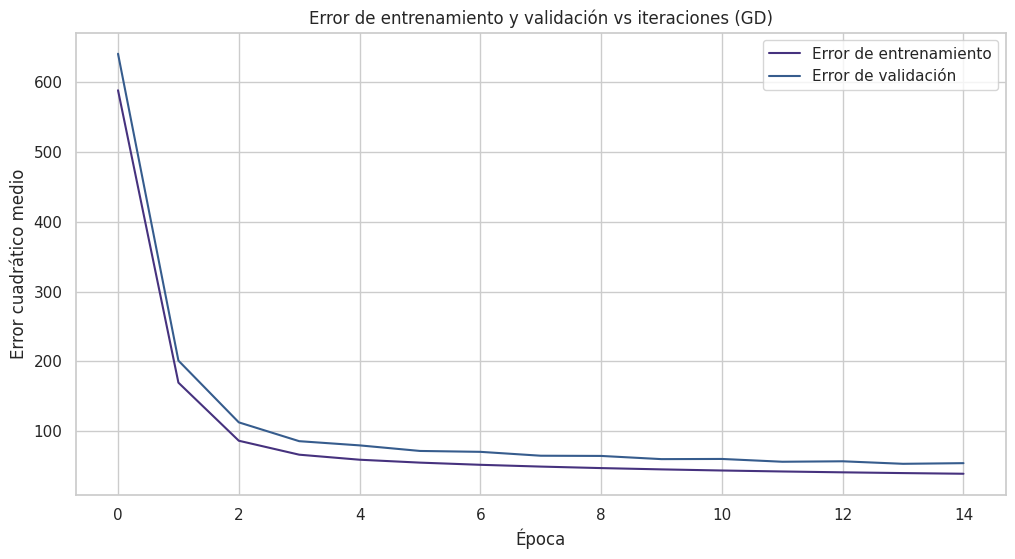

In [ ]:
W_batch = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.19, epochs=15)

### 4.2.3) Modelos Gradient Descent

#### 4.2.3.1) Gradient Descent

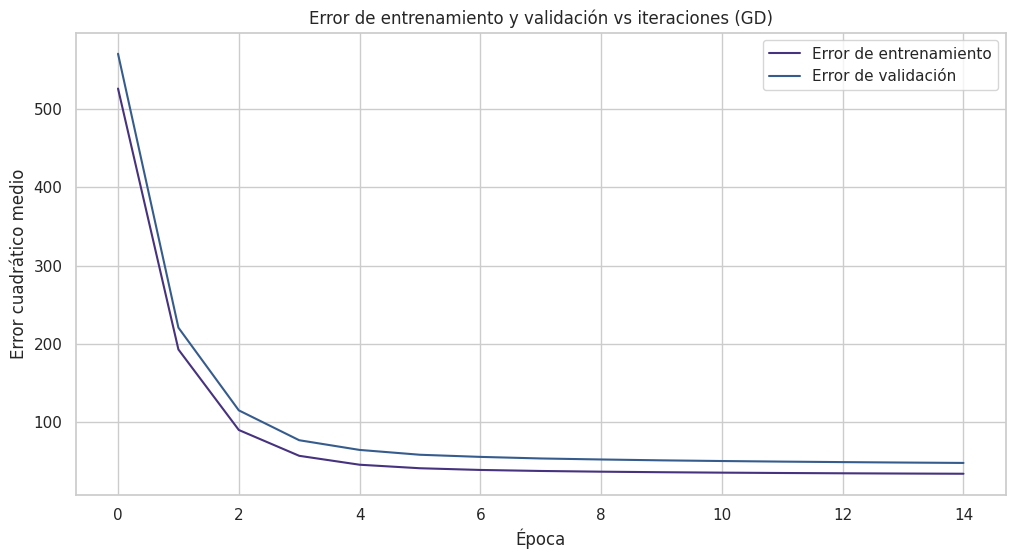

array([[ 1.56618049e+01],
       [ 2.43978427e-01],
       [-1.24277167e+00],
       [ 8.70991666e-01],
       [ 4.11499419e-01],
       [-2.17876083e-03],
       [-6.27721542e-01],
       [-1.20099402e+00],
       [-1.54877981e+00],
       [-6.23559370e+00],
       [ 1.14330551e+00],
       [ 3.74665114e+00],
       [ 2.72580148e+00],
       [ 4.58859292e+00],
       [ 7.57797991e+00]])

In [ ]:
gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.15, epochs=15)


In [ ]:
lr_gd_optimo = 0.15
epochs_gd_optimo = 20

1) Se ha incrementado el learning rate hasta 0.3; mas alla de este valor la curva de perdida comienza a comportarse de manera inestable en sucesivos calculos.
2) Para dicho learning rate se ha establecido que tras 15 epochs se logra un buen ajuste.

#### 4.2.3.2) Stochastic Gradient Descent

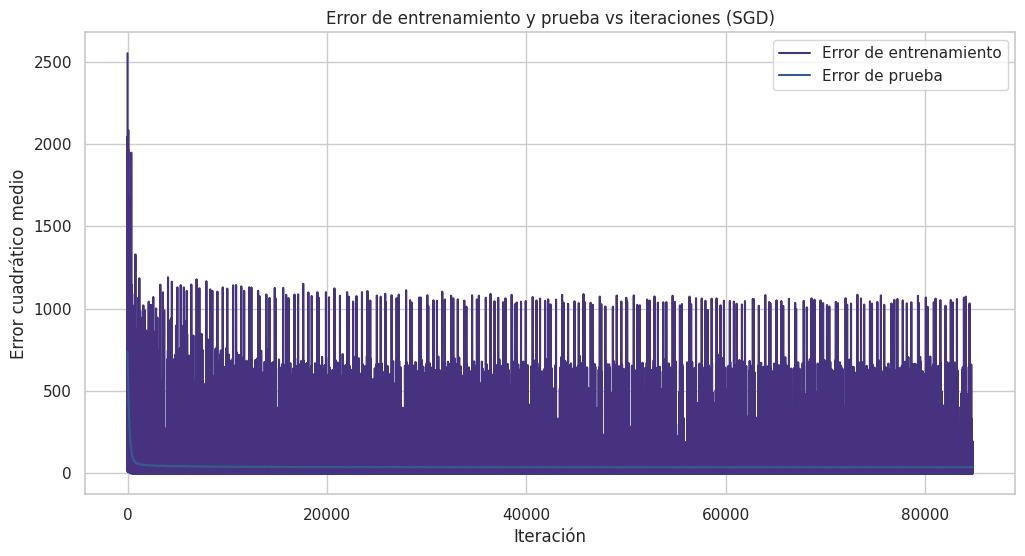

array([[21.21541468],
       [-0.457078  ],
       [-1.89353128],
       [ 2.0587839 ],
       [ 1.91226387],
       [-1.3692617 ],
       [-2.35976002],
       [-0.85795151],
       [-1.6523791 ],
       [-6.09605627],
       [-1.72892915],
       [ 2.37646756],
       [ 4.67978447],
       [ 0.6391138 ],
       [ 0.34607316]])

In [ ]:
stochastic_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.001, epochs=200)


In [ ]:
lr_sgd_optimo = 0.001
epochs_sgd_optimo = epochs=200

Aunque el error de entrenamiento muestra comportamiento ciclico (de esperarse) el error de prueba se estabiliza con los hiperparametros fijados.

#### 4.2.3.3) Mini Batch Gradient Descent

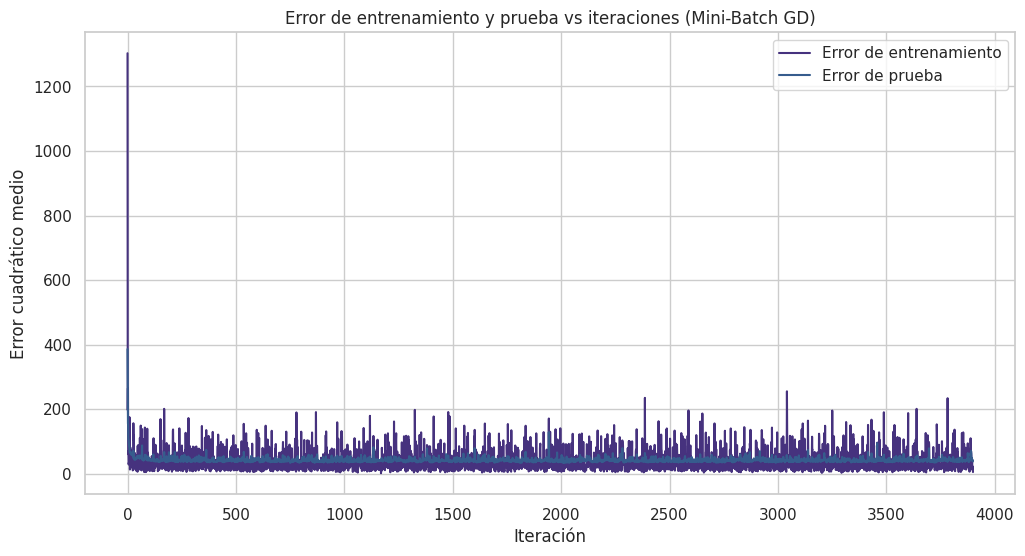

array([[ 2.11133890e+01],
       [ 8.59648633e-02],
       [-1.45124262e+00],
       [ 9.67826227e-01],
       [ 1.91663861e+00],
       [-1.73742888e+00],
       [-2.55282191e+00],
       [-3.26934643e-01],
       [-1.23599092e+00],
       [-6.08742233e+00],
       [-1.97985540e+00],
       [ 2.39242515e+00],
       [ 5.40591439e+00],
       [ 4.99947755e-01],
       [-1.60965440e-02]])

In [ ]:
mini_batch_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=100,batch_size=11)


In [ ]:
lr_mbgd_optimo = 0.1
epochs_mbgd_optimo = 100
batch_size_mbgd_optimo=11

## 4.3) Regularización

#### 4.3.1) Lasso

In [ ]:
pipeline_modelo_Lasso = Pipeline([
    ('preprocesador', preprocesador),
    ('regressor', Lasso(alpha=0.001))
])

pipeline_modelo_Lasso.fit(X_train_clean, y_train)

#Generar predicciones para ambos conjuntos
y_pred_train = pipeline_modelo_Lasso.predict(X_train_clean)
y_pred_test = pipeline_modelo_Lasso.predict(X_test_clean)

#Calcular las métricas
def calcular_metricas(y_real, y_pred, nombre_conjunto):
    return {
        'Conjunto': nombre_conjunto,
        'R² Score': r2_score(y_real, y_pred),
        'MSE': mean_squared_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

# Calcular métricas para train y test
metricas_train = calcular_metricas(y_train, y_pred_train, 'Entrenamiento (Train)')
metricas_test = calcular_metricas(y_test, y_pred_test, 'Prueba (Test)')

# Crear tabla comparativa
df_comparacion = pd.DataFrame([metricas_train, metricas_test])
df_comparacion.set_index('Conjunto', inplace=True)

display(df_comparacion)

,R² Score,MSE,RMSE,MAE
Conjunto,,,,
Entrenamiento (Train),0.6632,29.3739,5.4198,3.7326
Prueba (Test),0.6237,36.4962,6.0412,4.0623


In [ ]:
alpha_lasso_optimo = 0

Aun con una penalizacion muy baja, el modelo ajusta y generaliza bien.

#### 4.3.2) Ridge

In [ ]:
pipeline_modelo_Ridge = Pipeline([
    ('preprocesador', preprocesador),
    ('regressor', Ridge(alpha=0.001))
])

pipeline_modelo_Ridge.fit(X_train_clean, y_train)

#Generar predicciones para ambos conjuntos
y_pred_train = pipeline_modelo_Ridge.predict(X_train_clean)
y_pred_test = pipeline_modelo_Ridge.predict(X_test_clean)

#Calcular las métricas
def calcular_metricas(y_real, y_pred, nombre_conjunto):
    return {
        'Conjunto': nombre_conjunto,
        'R² Score': r2_score(y_real, y_pred),
        'MSE': mean_squared_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

# Calcular métricas para train y test
metricas_train = calcular_metricas(y_train, y_pred_train, 'Entrenamiento (Train)')
metricas_test = calcular_metricas(y_test, y_pred_test, 'Prueba (Test)')

# Crear tabla comparativa
df_comparacion = pd.DataFrame([metricas_train, metricas_test])
df_comparacion.set_index('Conjunto', inplace=True)

display(df_comparacion)

,R² Score,MSE,RMSE,MAE
Conjunto,,,,
Entrenamiento (Train),0.6632,29.3738,5.4198,3.7333
Prueba (Test),0.6239,36.4696,6.0390,4.0622


In [ ]:
alpha_ridge_optimo = 0.01

#### 4.3.3) Elastic Net

In [ ]:
pipeline_modelo_ElasticNet = Pipeline([
    ('preprocesador', preprocesador),
    ('regressor', ElasticNet(alpha=0.001))
])

pipeline_modelo_ElasticNet.fit(X_train_clean, y_train)

# 2. Generar predicciones para ambos conjuntos
y_pred_train = pipeline_modelo_ElasticNet.predict(X_train_clean)
y_pred_test = pipeline_modelo_ElasticNet.predict(X_test_clean)

# 3. Función auxiliar para calcular las métricas solicitadas
def calcular_metricas(y_real, y_pred, nombre_conjunto):
    return {
        'Conjunto': nombre_conjunto,
        'R² Score': r2_score(y_real, y_pred),
        'MSE': mean_squared_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred)
    }

# Calcular métricas para train y test
metricas_train = calcular_metricas(y_train, y_pred_train, 'Entrenamiento (Train)')
metricas_test = calcular_metricas(y_test, y_pred_test, 'Prueba (Test)')

# Crear tabla comparativa
df_comparacion = pd.DataFrame([metricas_train, metricas_test])
df_comparacion.set_index('Conjunto', inplace=True)

display(df_comparacion)

,R² Score,MSE,RMSE,MAE
Conjunto,,,,
Entrenamiento (Train),0.6632,29.3741,5.4198,3.7317
Prueba (Test),0.6236,36.5069,6.0421,4.0620


# 5) Comparacion Modelos

In [ ]:
def obtener_metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {
        'R2': r2_score(y_real, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_real, y_pred),
        'MAPE': mean_absolute_percentage_error(y_real, y_pred)
    }

In [ ]:
# Función para predecir con los pesos 'W' de los modelos de Descenso de Gradiente
def predecir_gd(X, W):
    """
    Predice utilizando los pesos W.
    Fuerza la salida a un array 1D (n,) para compatibilidad con sklearn metrics.
    """
    n = X.shape[0]
    X_con_unos = np.hstack((np.ones((n, 1)), X))

    # Realiza la multiplicación de matrices.
    # El resultado natural será (n, 1) si W es (m+1, 1)
    y_pred = np.matmul(X_con_unos, W)

    # MUY IMPORTANTE: Aplanar la salida (flatten o ravel) a (n,) para evitar errores de dimensionalidad al comparar con y_true en pandas/sklearn
    return y_pred.ravel()

In [ ]:
resultados = []

In [ ]:
#  EVALUACIÓN DE MODELOS SCIKIT-LEARN (PIPELINES)
# Diccionario con los pipelines
modelos_sklearn = {
    'Regresión Lineal Múltiple': pipeline_modelo_Linear_Regression,
    'Regresión Lasso': pipeline_modelo_Lasso,
    'Regresión Ridge': pipeline_modelo_Ridge,
    'Regresión ElasticNet': pipeline_modelo_ElasticNet
}

for nombre, modelo in modelos_sklearn.items():
    # Predicciones
    y_pred_train = modelo.predict(X_train_clean)
    y_pred_test = modelo.predict(X_test_clean)

    # Cálculo de métricas
    met_train = obtener_metricas(y_train, y_pred_train)
    met_test = obtener_metricas(y_test, y_pred_test)

    # Guardar en la lista
    resultados.append({
        'Modelo': nombre,
        'Train_R2': met_train['R2'], 'Test_R2': met_test['R2'],
        'Train_MSE': met_train['MSE'], 'Test_MSE': met_test['MSE'],
        'Train_RMSE': met_train['RMSE'], 'Test_RMSE': met_test['RMSE'],
        'Train_MAE': met_train['MAE'], 'Test_MAE': met_test['MAE'],
        'Train_MAPE': met_train['MAPE'], 'Test_MAPE': met_test['MAPE']
    })

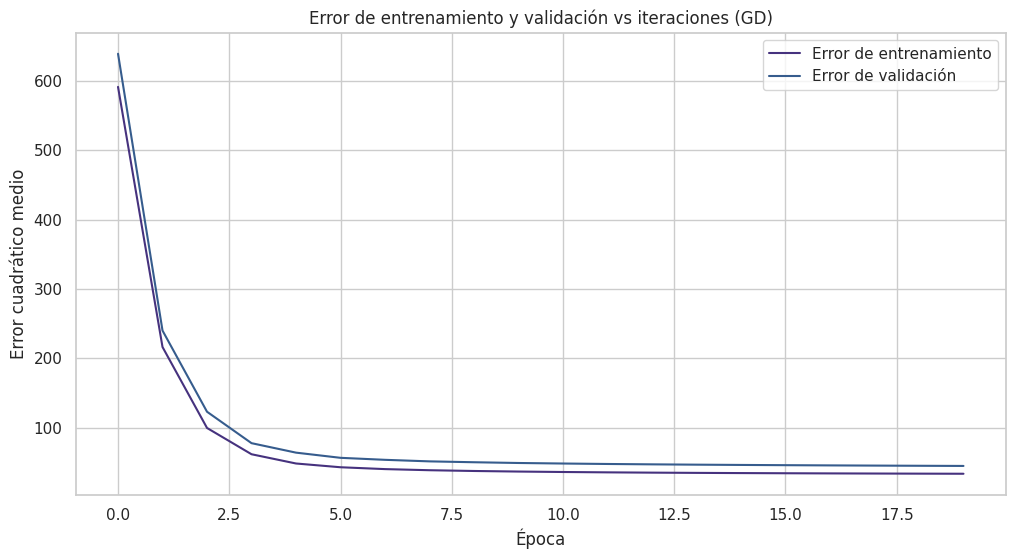

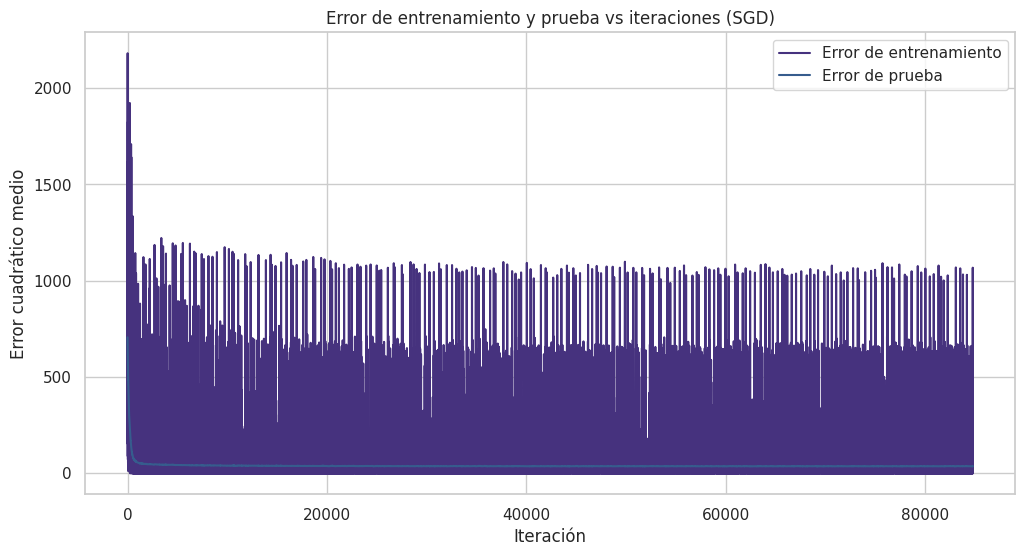

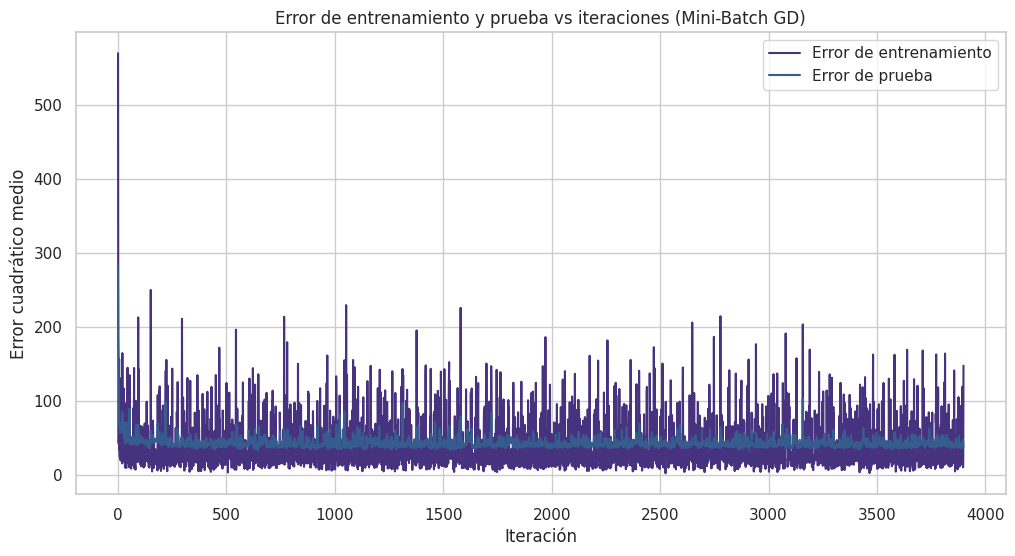

In [ ]:
# EVALUACIÓN DE (DESCENSO GRADIENTE)

# Ejecutamos las funciones manuales.
# Nota: Pasamos y_train_np y y_test_np para el cálculo del error interno,
# pero X debe ser el conjunto escalado (X_train_np / X_test_np)
W_batch = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr_gd_optimo, epochs_gd_optimo)
W_stocastic = stochastic_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr_sgd_optimo, epochs_sgd_optimo)
W_minibatch = mini_batch_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr_mbgd_optimo, epochs_mbgd_optimo, batch_size_mbgd_optimo)

modelos_manuales = {
    'GD Común (Batch)': W_batch,
    'GD Estocástico': W_stocastic,
    'GD Mini-batch': W_minibatch
}

for nombre, W in modelos_manuales.items():
    # Predicciones usando los arrays escalados
    y_pred_train = predecir_gd(X_train_np, W)
    y_pred_test = predecir_gd(X_test_np, W)

    # Para calcular las métricas, necesitamos que las 'y_reales'
    # también sean 1D. Utilizamos .ravel() por seguridad.
    met_train = obtener_metricas(y_train_np.ravel(), y_pred_train)
    met_test = obtener_metricas(y_test_np.ravel(), y_pred_test)

    # Guardar en la lista (reutilizando la lista 'resultados' del bloque A)
    resultados.append({
        'Modelo': nombre,
        'Train_R2': met_train['R2'], 'Test_R2': met_test['R2'],
        'Train_MSE': met_train['MSE'], 'Test_MSE': met_test['MSE'],
        'Train_RMSE': met_train['RMSE'], 'Test_RMSE': met_test['RMSE'],
        'Train_MAE': met_train['MAE'], 'Test_MAE': met_test['MAE'],
        'Train_MAPE': met_train['MAPE'], 'Test_MAPE': met_test['MAPE']
    })

In [ ]:
#Crear el DataFrame final y mostrar los resultados
df_comparacion = pd.DataFrame(resultados)
df_comparacion.set_index('Modelo', inplace=True)

# Formatear el DataFrame para facilitar la lectura
# Muestra todas las columnas del DataFrame de forma clara
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print(df_comparacion.round(4)) # Redondeamos a 4 decimales

                           Train_R2  Test_R2  Train_MSE  Test_MSE  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_MAPE  Test_MAPE
Modelo                                                                                                                              
Regresión Lineal Múltiple    0.6632   0.6239    29.3738   36.4695      5.4198     6.0390     3.7333    4.0622      0.1856     0.1809
Regresión Lasso              0.6632   0.6237    29.3739   36.4962      5.4198     6.0412     3.7326    4.0623      0.1855     0.1809
Regresión Ridge              0.6632   0.6239    29.3738   36.4696      5.4198     6.0390     3.7333    4.0622      0.1856     0.1809
Regresión ElasticNet         0.6632   0.6236    29.3741   36.5069      5.4198     6.0421     3.7317    4.0620      0.1855     0.1808
GD Común (Batch)             0.6177   0.5409    33.3446   44.5221      5.7745     6.6725     3.8886    4.3482      0.1937     0.1881
GD Estocástico               0.6631   0.6227    29.3822   36.5903    

Dada la naturaleza del tipo de datos (social) consideramos que el ajuste del modelo ha sido muy bueno. Procedemos a elaborar conclusiones.

**Modelos Analíticos vs. Regularizados (OLS, Ridge, Lasso, ElasticNet)**

Comportamiento idéntico: La Regresión Lineal Múltiple, Ridge, Lasso y ElasticNet muestran metricas muy similares (Train_R2 = 0.6632 y Test_R2 ≈ 0.6239).   

Interpretación: Esto indica que los hiperparámetros de regularización (como el alpha) probablemente sean muy pequeños, o que el modelo no sufre de un sobreajuste severo por multicolinealidad, haciendo que la penalización tenga un efecto mínimo y los coeficientes se mantengan muy cercanos a los de la regresión lineal tradicional.

**Rendimiento de los Métodos por Gradient Descent**

GD Estocástico: Es el que mejor se desempeña entre los métodos iterativos, logrando un Test_R2 de 0.6227 y un Test_RMSE de 6.0490, quedándose muy cerca de los resultados analíticos exactos.

Esto muestra que alinear de la tasa de aprendizaje y las iteraciones dio buenos resultados.   

GD Mini-batch: Muestra un rendimiento  cercano (Test_R2 = 0.6203), posicionándose como una alternativa intermedia.   

GD Común (Batch): Presenta el rendimiento más bajo (Test_R2 = 0.5409 y un Test_RMSE elevado de 6.6725), puede ser que haya sido necesaria optimizacion mas precisa de hiperparametros.   



Dados los resultados, como las metricas son similares, seleccionamos el modelo de *Regresion Lineal Multiple*; dado que es el que mostró mejores metricas y mayor simpleza y no se tienen suficientes variables que ameriten reemplazar por un metodo de calculo como el GD.